# Radiation Model Research

**Testing Linear No-Threshold Model for Radiation Level using Machine Learning and Neural Network**

*What is Linear No-Threshold (LNT) model*

Linear No Threshold model is the globaly accepted model to determine propotional harm caused by radiation to a individual. As stated in the name itself the model sets no threshold for safe radiation exposer, i.e radiation no matter how small is harmful. This was formulated after the Life Span Study (LSS) of the atomic bomb survivors in Hiroshima and Nagasaki. The lack of a threshold is due to the belief that any dose of ionizing radiation, no matter how small, carries a risk of cancer. This led to ALARA (As Low As Reasonably Achievable) as our aim with radiation exposure.

*Life Span Study (LSS)* 

After the atomic bomb explosion in Japan, LSS was started to study the affeces radiation had on survivors. This study later became the basis of our nuclear safety standard as it is the backbone behind LNT. Using LSS as a basis for radiation exposer comes with its probelms, dose-rate being the biggest one. Nuclear explosion is a acute exposer event (high exposer in short period of time) using this data to extrapolate risk for chronic exposer (low exposer over extended period of time) is biologically incompatable. But this was and remains the gold standard for radiation study due to its massive statistical number (120,000 + individuals), demographic diversity, complete dose spectrum and its long term - high quality follow up, hence LSS will also remain as the backbone for our ML model.

<h2>Code</h2>

In [2]:
import pandas as pd
import numpy as np
from numpy.linalg import lstsq
from pathlib import Path
import time
import openpyxl
import matplotlib.pyplot as plt
import matplotlib; matplotlib.use('Agg')
import matplotlib.gridspec as gridspec
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import PartialDependenceDisplay
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from scipy import stats, optimize
from scipy.stats import linregress, gaussian_kde
from scipy.special import gammaln
import os
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
from tqdm import tqdm
import json
import pickle
import warnings; warnings.filterwarnings('ignore')

Plotting LNT line

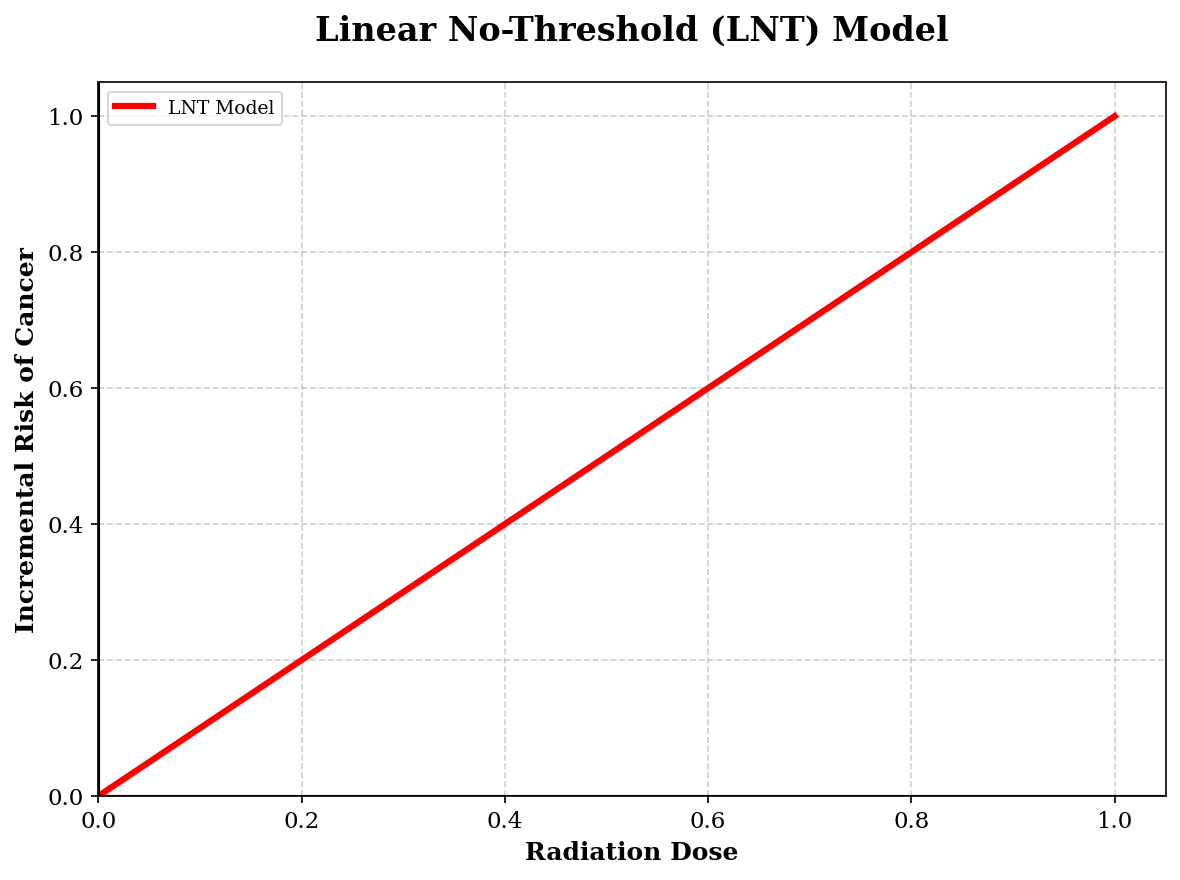

In [3]:
%matplotlib inline

def plot_simple_lnt():
    dose = np.linspace(0, 1, 100)
    
    risk = dose 

    plt.figure(figsize=(8, 6))

    plt.plot(dose, risk, color='red', linewidth=3, label='LNT Model')

    plt.title('Linear No-Threshold (LNT) Model', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Radiation Dose', fontsize=12, fontweight='semibold')
    plt.ylabel('Incremental Risk of Cancer', fontsize=12, fontweight='semibold')

    plt.xlim(0, 1.05)
    plt.ylim(0, 1.05)
    
    plt.axvline(0, color='black', linewidth=1.5)
    plt.axhline(0, color='black', linewidth=1.5)

    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(loc='upper left')
    
    plt.tight_layout()
    plt.savefig('all charts/lnt_model.png')
    plt.show()
    
plot_simple_lnt()

*<h2>Analyzing LSS data</h2>*

Load Data

In [4]:
df = pd.read_csv('Data/lss14.csv')

ERR check for Data validity

In [5]:
%matplotlib inline

df['dose_sv'] = df['colon10'] / 1000.0

df_clean = df[df['pyr'] > 0].copy()
    
formula = "solid ~ dose_sv + C(sex) + C(agecat) + C(city)"
    
model = smf.glm(
        formula=formula, 
        data=df_clean, 
        offset=np.log(df_clean['pyr']), 
        family=sm.families.Poisson()
    )

result = model.fit()

beta = result.params['dose_sv']
    
err_at_1sv = np.exp(beta * 1.0) - 1

print("--- LSS ERR Calculation Results ---")
print(f"Regression Coefficient (Beta): {beta:.4f}")
print(f"Excess Relative Risk (ERR) at 1 Sv: {err_at_1sv:.4f} ({err_at_1sv*100:.2f}%)")
print("\nInterpretation:")
print(f"For every 1 Sv of dose, the cancer risk increases by approximately {err_at_1sv*100:.1f}%.")
print(f"This aligns with the standard '40-60%' ERR often cited for solid cancer in LSS data.")



--- LSS ERR Calculation Results ---
Regression Coefficient (Beta): 0.3513
Excess Relative Risk (ERR) at 1 Sv: 0.4209 (42.09%)

Interpretation:
For every 1 Sv of dose, the cancer risk increases by approximately 42.1%.
This aligns with the standard '40-60%' ERR often cited for solid cancer in LSS data.


Subject Age Distribution:

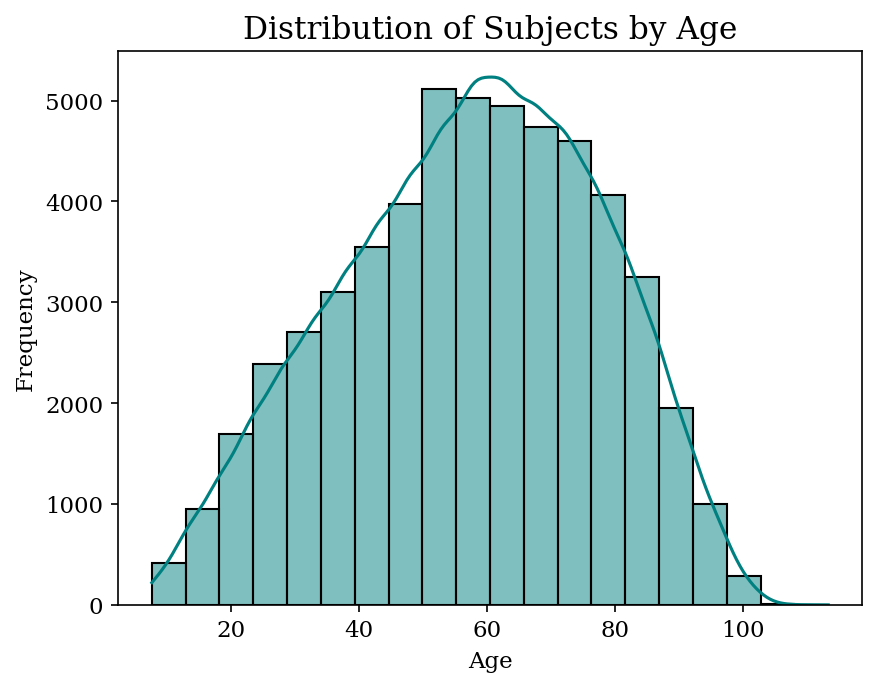

In [6]:
plt.figure()
sns.histplot(df['age'], bins=20, kde=True, color='teal')
plt.title('Distribution of Subjects by Age', fontsize=15)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.savefig('all charts/Distribution_of_Subjects_by_Age.png')
plt.show()

Quantifying Low Dose vs High Dose

--- Ratio by Person-Years (Statistical Weight) ---
Threshold (mSv) Low Dose (mSv) High Dose (mSv) Ratio (High/Low) % Data is Low Dose
------------------------------------------------------------------------------------------
20.00           2022576         1271706         0.6288               61.4%
50.00           2400342         893941          0.3724               72.9%
80.00           2530659         763623          0.3017               76.8%
100.00          2609197         685085          0.2626               79.2%


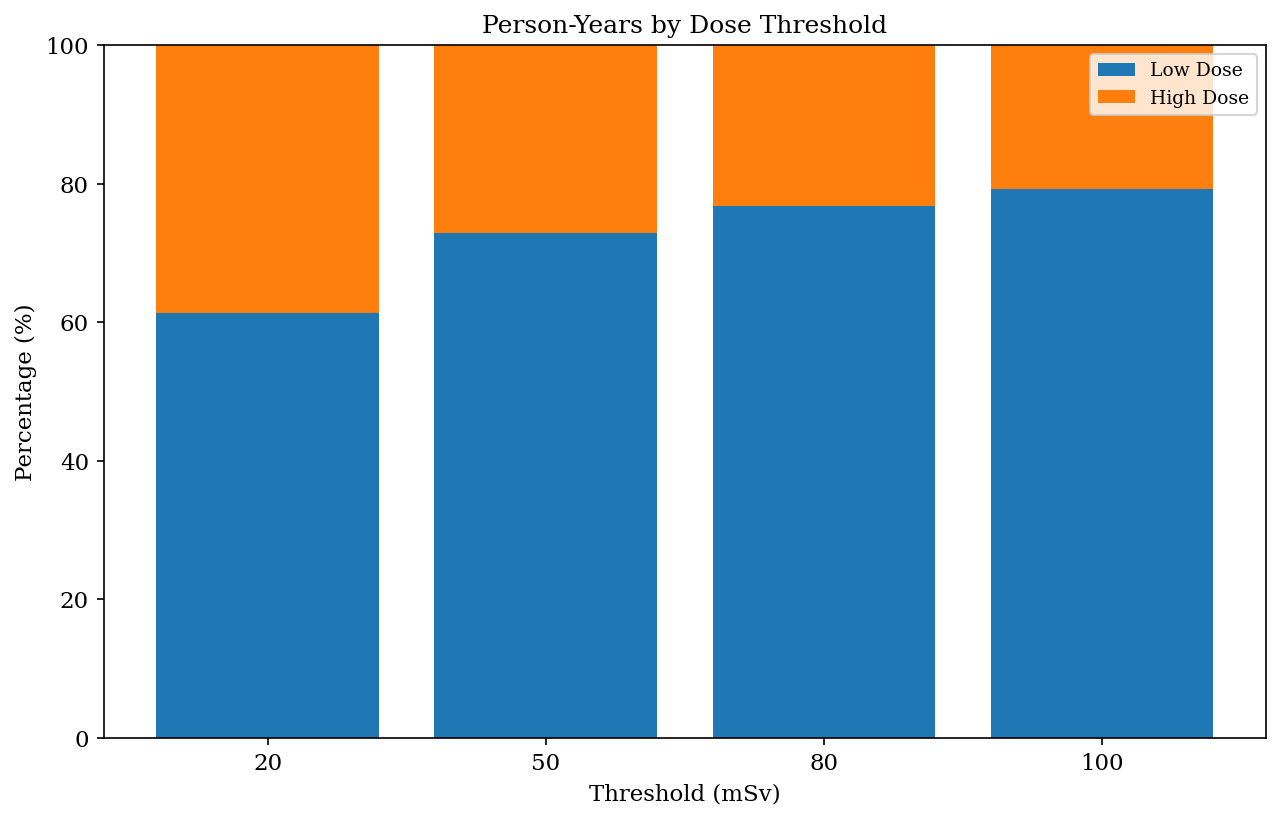

In [7]:
df['dose_gy'] = df['colon10']

thresholds = [20, 50, 80, 100]

print("--- Ratio by Person-Years (Statistical Weight) ---")
print(f"{'Threshold (mSv)'} {'Low Dose (mSv)'} {'High Dose (mSv)'} {'Ratio (High/Low)'} {'% Data is Low Dose'}")
print("-" * 90)

plot_thresholds = []
plot_low = []
plot_high = []

for thresh in thresholds:
    low_mask = df['dose_gy'] <= thresh
    high_mask = df['dose_gy'] > thresh
    
    low_pyr = df.loc[low_mask, 'pyr'].sum()
    high_pyr = df.loc[high_mask, 'pyr'].sum()

    ratio = high_pyr / low_pyr if low_pyr > 0 else 0
    percent_low = (low_pyr / (low_pyr + high_pyr)) * 100
    
    print(f"{thresh:<15.2f} {low_pyr:<15.0f} {high_pyr:<15.0f} {ratio:<20.4f} {percent_low:.1f}%")
    
    plot_thresholds.append(str(thresh))
    plot_low.append(percent_low)
    plot_high.append(100 - percent_low)

plt.figure(figsize=(10, 6))
plt.bar(plot_thresholds, plot_low, label='Low Dose')
plt.bar(plot_thresholds, plot_high, bottom=plot_low, label='High Dose')
plt.xlabel('Threshold (mSv)')
plt.ylabel('Percentage (%)')
plt.ylim(0, 100)
plt.title('Person-Years by Dose Threshold')
plt.legend()
plt.savefig('all charts/person_years_chart.png', bbox_inches='tight')
plt.show()

Doescat grouped survivor vs deaths

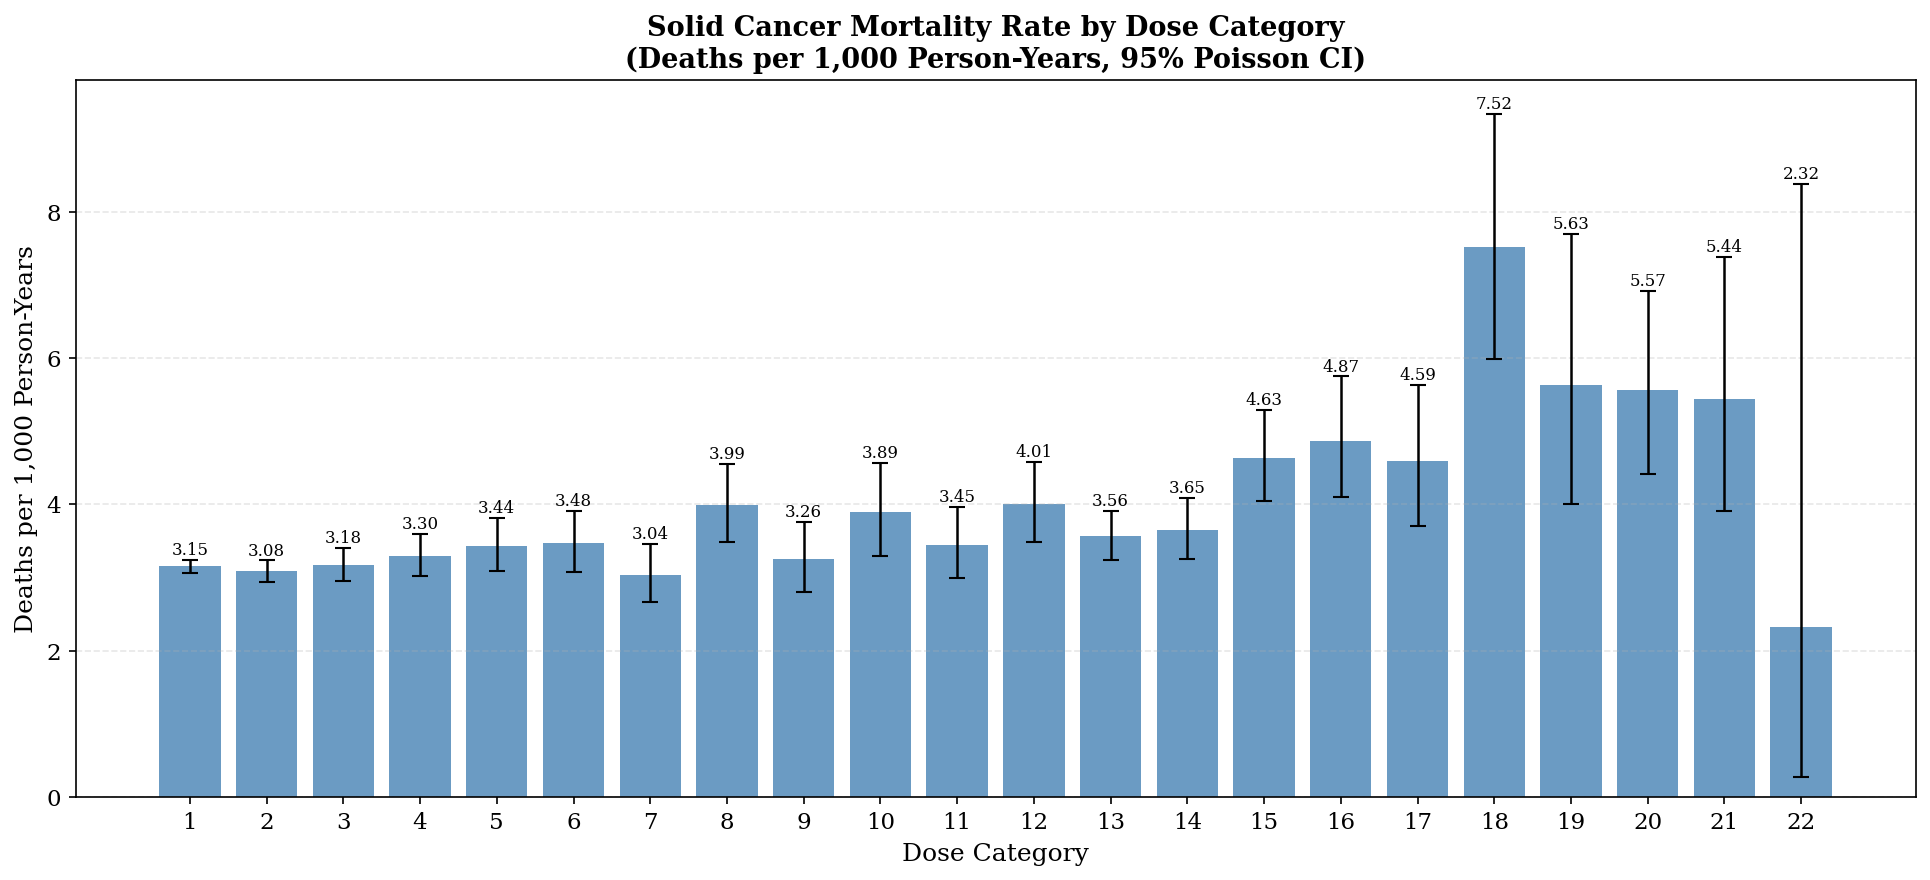

In [8]:
grouped = df.groupby('dosecat')[['solid', 'pyr']].sum().reset_index()

grouped['rate_per_1000'] = (grouped['solid'] / grouped['pyr']) * 1000

def poisson_ci(deaths, pyr, scale=1000):
    lo = stats.chi2.ppf(0.025, 2 * deaths) / 2 if deaths > 0 else 0.0
    hi = stats.chi2.ppf(0.975, 2 * (deaths + 1)) / 2
    return (lo / pyr) * scale, (hi / pyr) * scale

grouped['ci_lo'], grouped['ci_hi'] = zip(*grouped.apply(
    lambda r: poisson_ci(r['solid'], r['pyr']), axis=1
))
grouped['err_lo'] = grouped['rate_per_1000'] - grouped['ci_lo']
grouped['err_hi'] = grouped['ci_hi'] - grouped['rate_per_1000']

fig, ax = plt.subplots(figsize=(13, 6))

x     = grouped['dosecat'].values
rates = grouped['rate_per_1000'].values
yerr  = np.array([grouped['err_lo'].values, grouped['err_hi'].values])

bars = ax.bar(x, rates, color='steelblue', alpha=0.8,
              yerr=yerr, capsize=4, error_kw={'linewidth': 1.2, 'color': 'black'})

for bar, rate in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + yerr[1][list(rates).index(rate)] + 0.02,
            f'{rate:.2f}', ha='center', va='bottom', fontsize=8)

ax.set_title("Solid Cancer Mortality Rate by Dose Category\n"
             "(Deaths per 1,000 Person-Years, 95% Poisson CI)",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Dose Category", fontsize=12)
ax.set_ylabel("Deaths per 1,000 Person-Years", fontsize=12)
ax.set_xticks(x)
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig("all charts/mortality_rate_by_dosecat.png", dpi=150, bbox_inches='tight')
plt.show(fig)


Mortality by Age

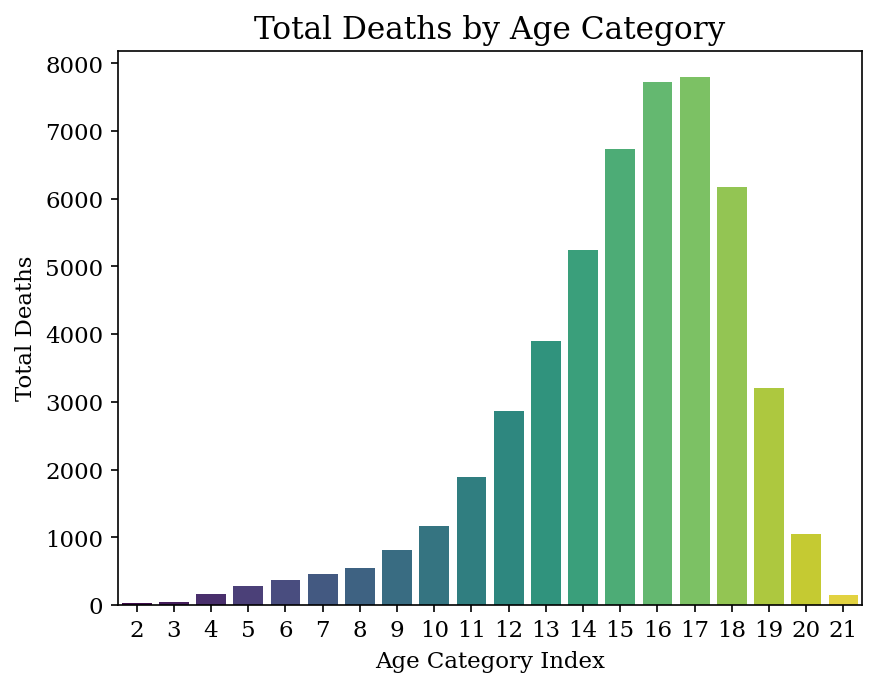

In [9]:
plt.figure()
age_death = df.groupby('agecat')['death'].sum().reset_index()

sns.barplot(
    data=age_death, 
    x='agecat', 
    y='death', 
    hue='agecat', 
    palette='viridis', 
    legend=False
)

plt.title('Total Deaths by Age Category', fontsize=15)
plt.xlabel('Age Category Index')
plt.ylabel('Total Deaths')
plt.savefig('all charts/total_deaths_by_agecat.png', bbox_inches='tight')
plt.show()

Age vs Solid Deaths

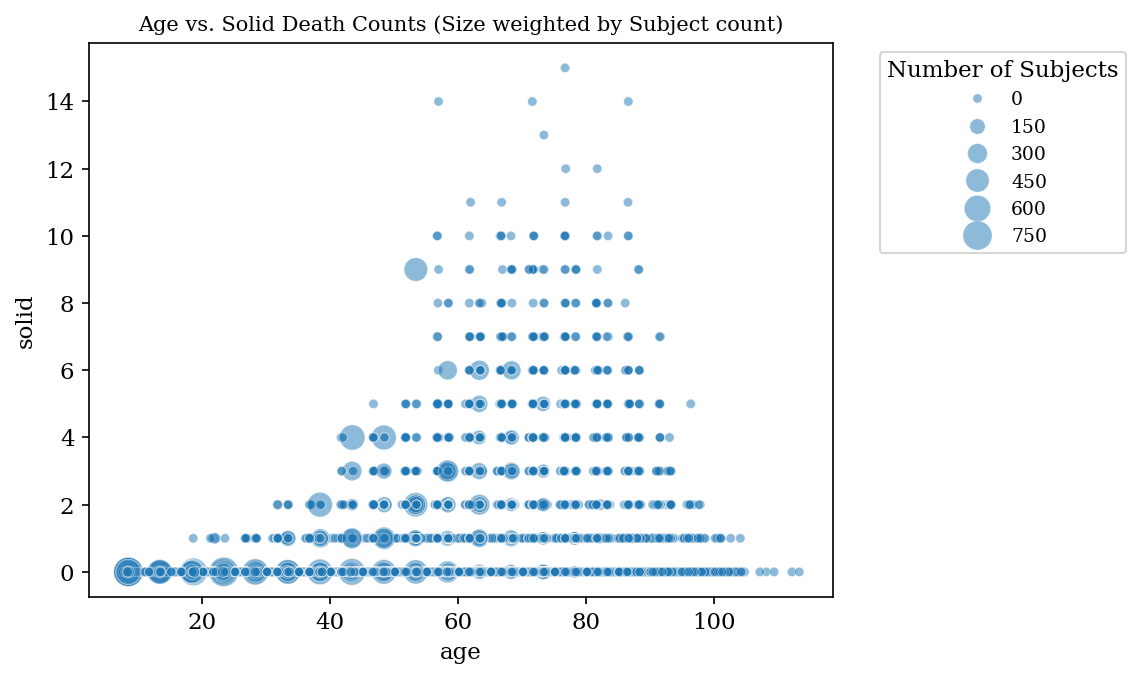

In [10]:
plt.figure()
sns.scatterplot(data=df, x='age', y='solid', alpha=0.5, size='subjects', sizes=(20, 200))
plt.title('Age vs. Solid Death Counts (Size weighted by Subject count)', fontsize=10)
plt.legend(title='Number of Subjects', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.savefig('all charts/age_vs_solid_deaths.png', bbox_inches='tight')
plt.show()

Mortality Rate by Dose Category


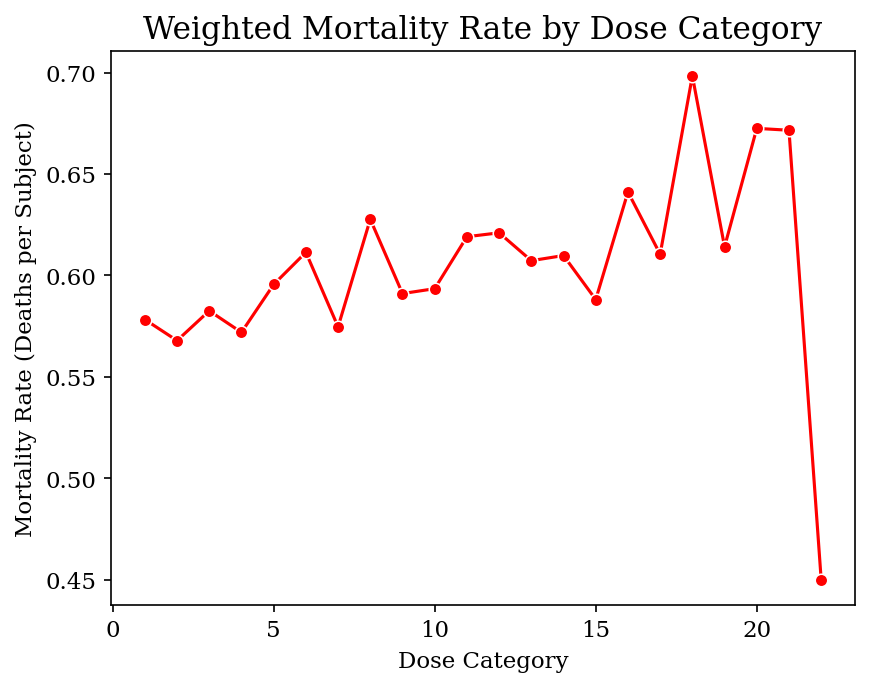

In [11]:
plt.figure()
dose_stats = df.groupby('dosecat').agg({'death': 'sum', 'subjects': 'sum'}).reset_index()
dose_stats['mortality_rate'] = dose_stats['death'] / dose_stats['subjects']

sns.lineplot(data=dose_stats, x='dosecat', y='mortality_rate', marker='o', color='red')
plt.title('Weighted Mortality Rate by Dose Category', fontsize=15)
plt.xlabel('Dose Category')
plt.ylabel('Mortality Rate (Deaths per Subject)')
plt.savefig('all charts/weighted_mortality_rate.png', bbox_inches='tight')
plt.show()

Cancer Type

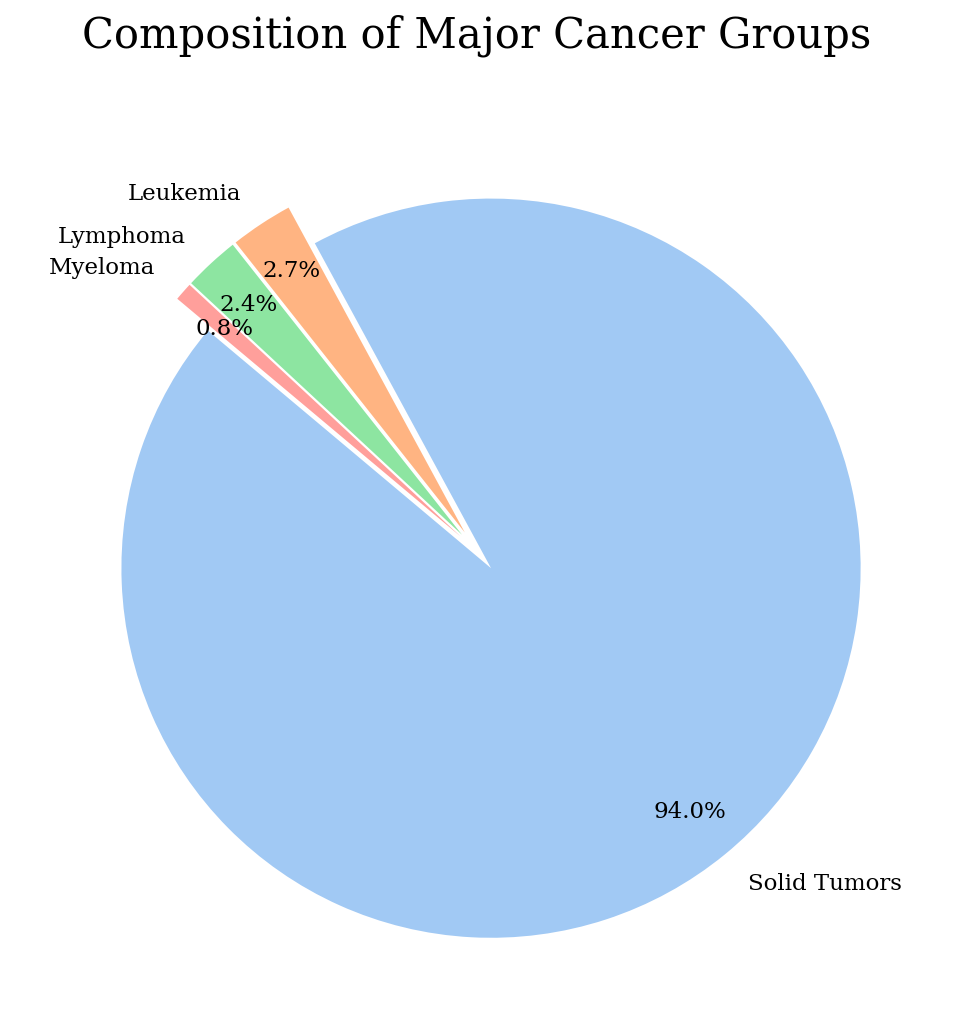

In [12]:
plt.figure(figsize=(11, 8))

cancer_types = {
    'Solid Tumors': df['solid'].sum(),
    'Leukemia': df['leukemia'].sum(),
    'Lymphoma': df['lymphoma'].sum(),
    'Myeloma': df['myeloma'].sum()
}

explode = (0.06, 0.06, 0.06, 0.06) 

plt.pie(
    cancer_types.values(), 
    labels=cancer_types.keys(), 
    autopct='%1.1f%%', 
    colors=sns.color_palette('pastel'), 
    startangle=140,
    explode=explode,   
    pctdistance=0.85,    
    labeldistance=1.1
)

plt.title('Composition of Major Cancer Groups', fontsize=20, pad=20)
plt.savefig('all charts/cancer_composition.png', bbox_inches='tight')
plt.show()

Where our data mostly sits

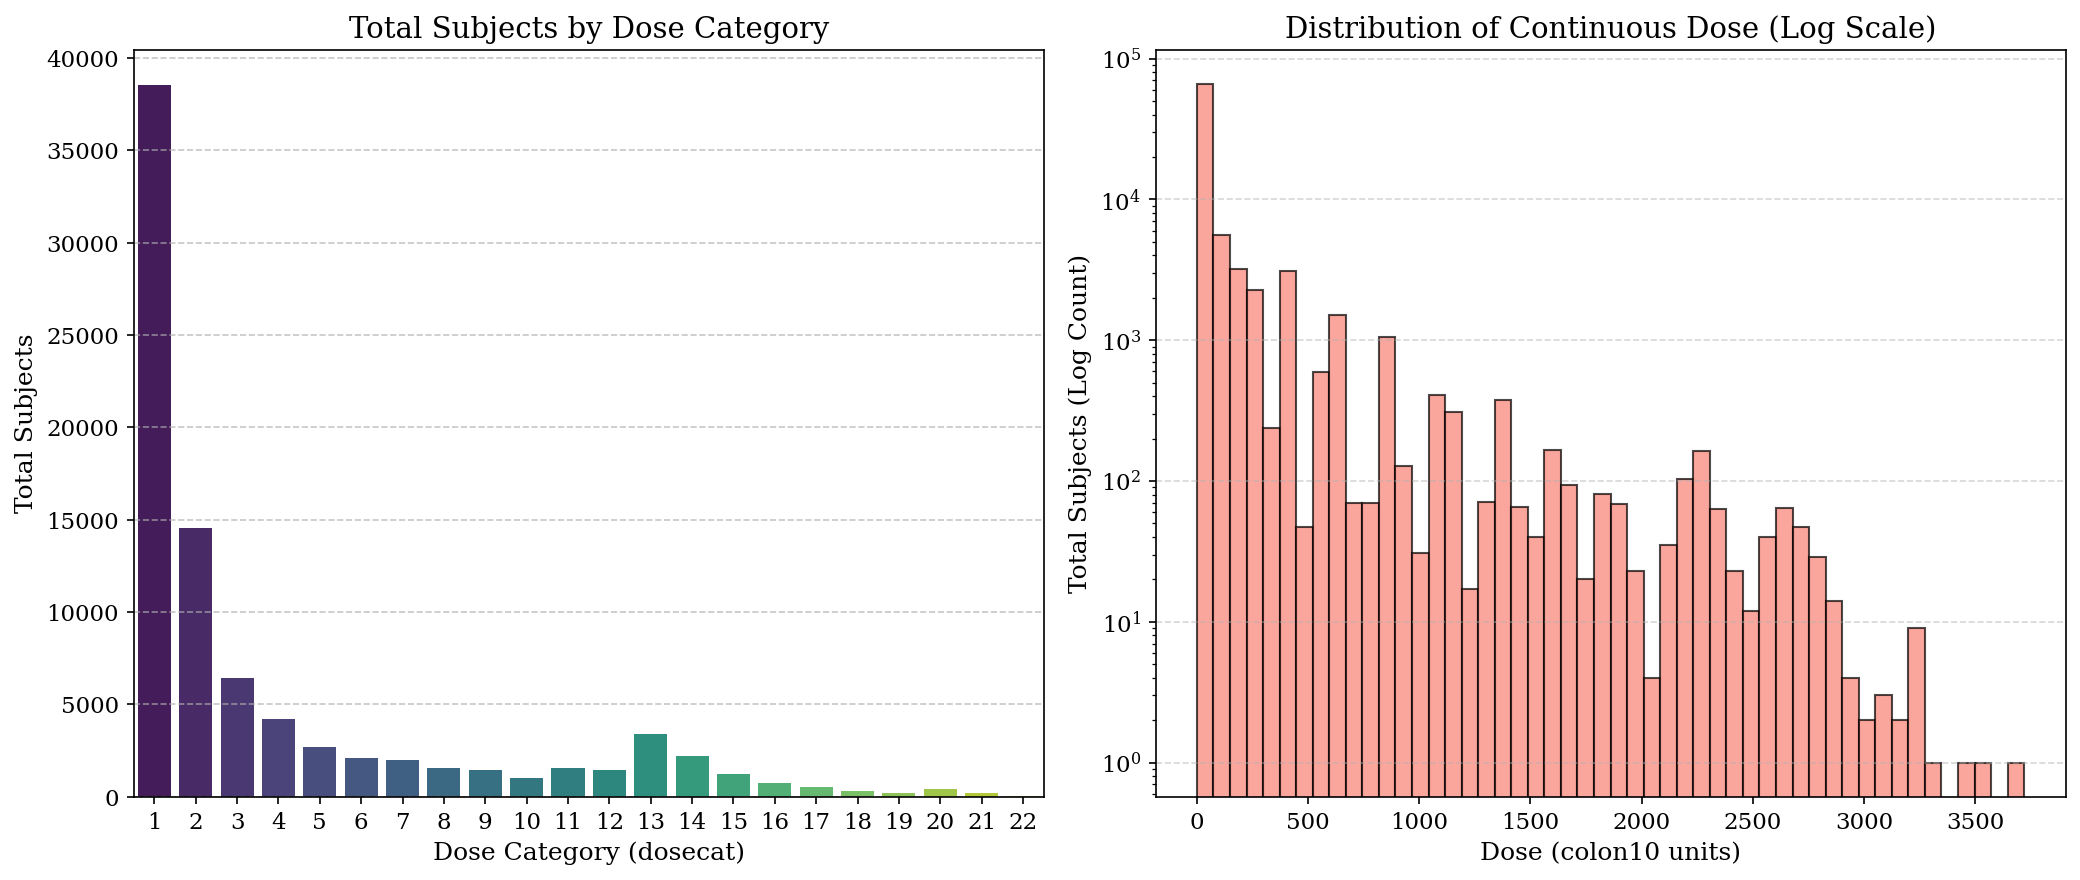

Total Subjects: 86,611
Subjects in 'Low Dose' categories (1-5): 66,388 (76.7%)


In [13]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
dose_counts = df.groupby('dosecat')['subjects'].sum().reset_index()
sns.barplot(data=dose_counts, x='dosecat', y='subjects', palette='viridis')
plt.title('Total Subjects by Dose Category', fontsize=14)
plt.xlabel('Dose Category (dosecat)', fontsize=12)
plt.ylabel('Total Subjects', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
plot_data = df[df['colon10'] >= 0] 

plt.hist(plot_data['colon10'], bins=50, weights=plot_data['subjects'], 
         color='salmon', edgecolor='black', alpha=0.7)
plt.yscale('log') 
plt.title('Distribution of Continuous Dose (Log Scale)', fontsize=14)
plt.xlabel('Dose (colon10 units)', fontsize=12)
plt.ylabel('Total Subjects (Log Count)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

total_subjects = df['subjects'].sum()
low_dose_subjects = df[df['dosecat'] <= 5]['subjects'].sum()
print(f"Total Subjects: {total_subjects:,.0f}")
print(f"Subjects in 'Low Dose' categories (1-5): {low_dose_subjects:,.0f} ({(low_dose_subjects/total_subjects)*100:.1f}%)")

NGAM with unfrozen Linear and Neural Branch running till 4Gy

Hardware: NVIDIA GPU (NVIDIA GeForce GTX 1650 Ti)
Loading LSS-14 data ...
Maximum dose in dataset: 3.7200 Gy

 Run : 'standard_0pct' | delta=0% | n_boot=200 | epochs=400


standard_0pct: 100%|██████████| 200/200 [06:51<00:00,  2.06s/it]



 Run : 'doss_adjusted_20pct' | delta=20% | n_boot=200 | epochs=400


doss_adjusted_20pct: 100%|██████████| 200/200 [06:45<00:00,  2.03s/it]




--- AUTO-GENERATED JSON OUTPUT ---
{
  "0.00_Gy": {
    "Standard_f_dose": {
      "Median": 0.0,
      "95_CI": [
        0.0,
        0.0
      ]
    },
    "Doss_Adjusted_f_dose": {
      "Median": 0.0,
      "95_CI": [
        0.0,
        0.0
      ]
    }
  },
  "0.05_Gy": {
    "Standard_f_dose": {
      "Median": -0.5411,
      "95_CI": [
        -0.8862,
        -0.2411
      ]
    },
    "Doss_Adjusted_f_dose": {
      "Median": -0.6088,
      "95_CI": [
        -0.9598,
        -0.2552
      ]
    }
  },
  "0.10_Gy": {
    "Standard_f_dose": {
      "Median": -0.8726,
      "95_CI": [
        -1.3054,
        -0.4312
      ]
    },
    "Doss_Adjusted_f_dose": {
      "Median": -0.9659,
      "95_CI": [
        -1.3798,
        -0.4437
      ]
    }
  },
  "0.15_Gy": {
    "Standard_f_dose": {
      "Median": -1.0329,
      "95_CI": [
        -1.4139,
        -0.5766
      ]
    },
    "Doss_Adjusted_f_dose": {
      "Median": -1.118,
      "95_CI": [
        -1.4697,
     

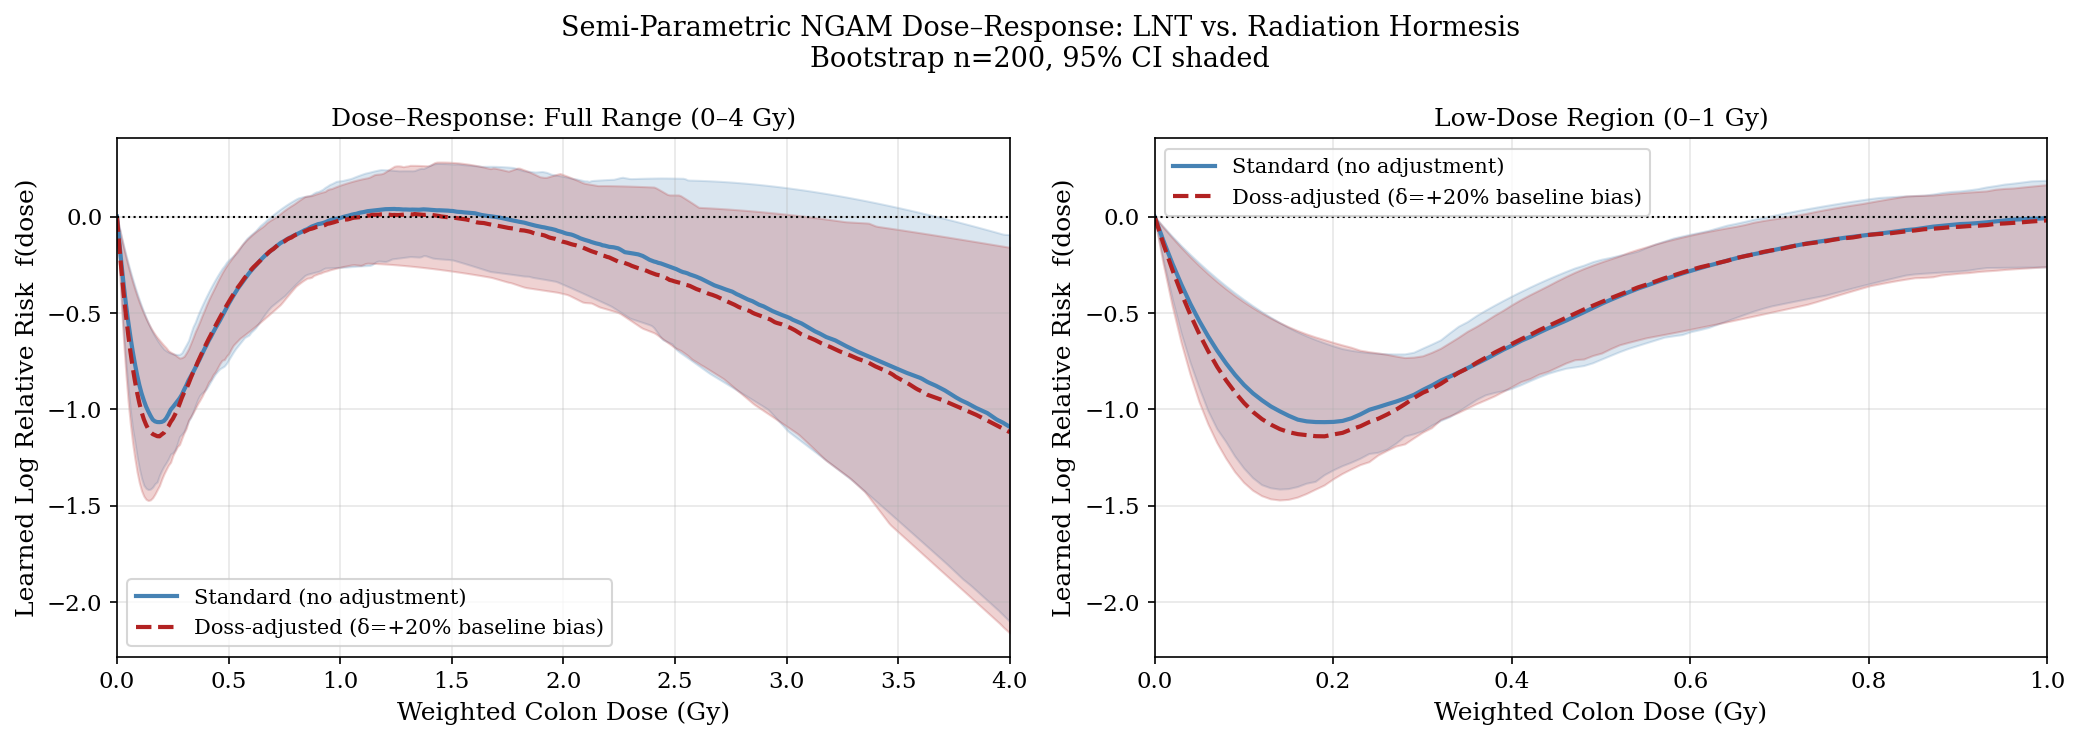

In [ ]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import json
from tqdm import tqdm

# ============================================================
# 0. Global Setup
# ============================================================
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    print(f"Hardware: NVIDIA GPU ({torch.cuda.get_device_name(0)})")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
    print("Hardware: Apple Silicon (MPS)")
else:
    DEVICE = torch.device("cpu")
    print("Hardware: CPU")

os.makedirs("trained_models", exist_ok=True)

# ============================================================
# 1. Semi-Parametric NGAM Architecture
# ============================================================
class PoissonNGAM(nn.Module):
    def __init__(self, num_linear_features: int):
        super().__init__()
        self.linear_branch = nn.Linear(num_linear_features, 1, bias=True)
        self.dose_linear_trend = nn.Linear(1, 1, bias=False)
        self.dose_mlp = nn.Sequential(
            nn.Linear(1, 16),
            nn.SiLU(),          
            nn.Linear(16, 16),
            nn.SiLU(),
            nn.Linear(16, 1),
        )

    def forward(self, x_lin, x_dose, offset):
        lin_effect = self.linear_branch(x_lin) 
        linear_dose_effect = self.dose_linear_trend(x_dose)
        raw_mlp = self.dose_mlp(x_dose)
        zero_mlp = self.dose_mlp(torch.zeros_like(x_dose))
        neural_dose_effect = raw_mlp - zero_mlp
        total_dose_effect = linear_dose_effect + neural_dose_effect
        log_lambda = lin_effect + total_dose_effect + offset
        return torch.exp(log_lambda)

    def get_dose_shape(self, x_dose):
        lin_eff = self.dose_linear_trend(x_dose)
        nn_eff = self.dose_mlp(x_dose) - self.dose_mlp(torch.zeros_like(x_dose))
        return lin_eff + nn_eff


# ============================================================
# 2. Data Preparation
# ============================================================
def preprocess_data(df: pd.DataFrame):
    df = df.copy()
    df["log_age"]  = np.log(df["age"])
    df["log_agex"] = np.log(df["agex"])
    df["log_pyr"]  = np.log(df["pyr"])

    cat_cols = ["city", "sex", "ctime", "gd3", "ahs"]
    df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

    dummy_cols = [c for c in df.columns if any(c.startswith(f"{b}_") for b in cat_cols)]
    for col in dummy_cols:
        df[col] = df[col].astype(np.float32)

    linear_features = dummy_cols + ["log_age", "log_agex"]

    X_lin  = df[linear_features].values.astype(np.float32)
    X_dose = df[["dose"]].values.astype(np.float32)
    Y      = df["solid"].values.astype(np.float32)
    Offset = df["log_pyr"].values.astype(np.float32)

    t_X_lin  = torch.tensor(X_lin,   device=DEVICE)
    t_X_dose = torch.tensor(X_dose,  device=DEVICE)
    t_Y      = torch.tensor(Y,       device=DEVICE).unsqueeze(1)
    t_Offset = torch.tensor(Offset,  device=DEVICE).unsqueeze(1)

    return t_X_lin, t_X_dose, t_Y, t_Offset, len(linear_features)


# ============================================================
# 3. Bootstrap Training Loop
# ============================================================
def bootstrap_ngam(
    t_X_lin, t_X_dose, t_Y, t_Offset, num_lin_features,
    baseline_bias_delta=0.0, n_bootstraps=50, epochs=200,
    lr=0.01, weight_decay=1e-4, patience=15, min_delta=1e-5,
    dose_grid_max=4.0, run_name="standard"
):
    N = t_X_lin.shape[0]
    n_grid = 400
    dose_grid = torch.linspace(0.0, dose_grid_max, n_grid, device=DEVICE).unsqueeze(1)
    loss_fn = nn.PoissonNLLLoss(log_input=False, full=True)
    all_shapes = []

    print(f"\n{'='*65}\n Run : '{run_name}' | delta={baseline_bias_delta*100:.0f}% | "
          f"n_boot={n_bootstraps} | epochs={epochs}\n{'='*65}")

    for b in tqdm(range(n_bootstraps), desc=run_name):
        idx      = torch.randint(0, N, (N,), device=DEVICE)
        b_X_lin  = t_X_lin[idx]
        b_X_dose = t_X_dose[idx]
        b_Y      = t_Y[idx]
        b_Offset = t_Offset[idx].clone()

        if baseline_bias_delta > 0.0:
            b_Offset = b_Offset + float(np.log(1.0 + baseline_bias_delta))

        model = PoissonNGAM(num_lin_features).to(DEVICE)
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=lr/100)

        best_loss = float("inf")
        patience_count = 0

        model.train()
        for _ in range(epochs):
            optimizer.zero_grad()
            preds = model(b_X_lin, b_X_dose, b_Offset)
            loss  = loss_fn(preds, b_Y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()
            scheduler.step()

            val = loss.item()
            if best_loss - val > min_delta:
                best_loss = val
                patience_count = 0
            else:
                patience_count += 1
            if patience_count >= patience:
                break

        model.eval()
        with torch.no_grad():
            shape = model.get_dose_shape(dose_grid).cpu().numpy().flatten()
        all_shapes.append(shape)

        torch.save(model.state_dict(), os.path.join("trained_models", f"ngam_{run_name}_boot_{b:03d}.pth"))

    return np.array(all_shapes), dose_grid.cpu().numpy().flatten()


# ============================================================
# 4. Main Execution & Auto-JSON
# ============================================================
if __name__ == "__main__":
    print("Loading LSS-14 data ...")
    df = pd.read_csv("Data/lss14.csv") 

    df["dose"] = df["colon10"] / 1000.0
    df = df[(df["dose"] >= 0.0) & (df["pyr"] > 0.0) & (df["age"] > 0.0) & (df["agex"] > 0.0)].copy()
    
    max_dose_in_data = df["dose"].max()
    print(f"Maximum dose in dataset: {max_dose_in_data:.4f} Gy")

    t_X_lin, t_X_dose, t_Y, t_Offset, num_lin_features = preprocess_data(df)

    N_BOOTSTRAPS  = 200
    EPOCHS        = 400
    DOSE_GRID_MAX = 4
    DELTA_DOSS    = 0.20

    shapes_std, dose_grid = bootstrap_ngam(
        t_X_lin, t_X_dose, t_Y, t_Offset, num_lin_features,
        baseline_bias_delta = 0.0, n_bootstraps=N_BOOTSTRAPS, epochs=EPOCHS,
        dose_grid_max=DOSE_GRID_MAX, run_name="standard_0pct"
    )

    shapes_doss, _ = bootstrap_ngam(
        t_X_lin, t_X_dose, t_Y, t_Offset, num_lin_features,
        baseline_bias_delta = DELTA_DOSS, n_bootstraps=N_BOOTSTRAPS, epochs=EPOCHS,
        dose_grid_max=DOSE_GRID_MAX, run_name=f"doss_adjusted_{int(DELTA_DOSS*100)}pct"
    )

    def boot_summary(shapes, q=(2.5, 50, 97.5)):
        return [np.percentile(shapes, qi, axis=0) for qi in q]

    std_lo,  std_med,  std_hi  = boot_summary(shapes_std)
    doss_lo, doss_med, doss_hi = boot_summary(shapes_doss)

    np.savez("Unfrozen_4Gy_npz/ngam_unfrozen_4gy.npz", dose_grid=dose_grid, shapes_std=shapes_std, shapes_doss=shapes_doss)
    
    # Plotting
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

    for ax, xlim, title in zip(axes, [DOSE_GRID_MAX, 1.0], ["Dose–Response: Full Range (0–4 Gy)", "Low-Dose Region (0–1 Gy)"]):
        ax.plot(dose_grid, std_med,  color="steelblue",  lw=2, label="Standard (no adjustment)")
        ax.fill_between(dose_grid, std_lo,  std_hi,  color="steelblue",  alpha=0.20)
        ax.plot(dose_grid, doss_med, color="firebrick", lw=2, linestyle="--", label=f"Doss-adjusted (δ=+{int(DELTA_DOSS*100)}% baseline bias)")
        ax.fill_between(dose_grid, doss_lo, doss_hi, color="firebrick", alpha=0.20)
        ax.axhline(0, color="black", lw=1.0, linestyle=":")
        ax.set_xlabel("Weighted Colon Dose (Gy)", fontsize=12)
        ax.set_ylabel("Learned Log Relative Risk  f(dose)", fontsize=12)
        ax.set_title(title, fontsize=12)
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.set_xlim(0, xlim)

    fig.suptitle(f"Semi-Parametric NGAM Dose–Response: LNT vs. Radiation Hormesis\nBootstrap n={N_BOOTSTRAPS}, 95% CI shaded", fontsize=13)
    plt.tight_layout()
    plt.savefig("PDF/ngam_unfrozen_4gy.pdf", dpi=300)
    plt.savefig("all charts/ngam_unfrozen_4gy.png", dpi=300)
    
    # ==========================================
    # Auto-Extract JSON
    # ==========================================
    target_doses = [0.0, 0.05, 0.1, 0.15, 0.2, 0.3, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0, 3.5, 3.72, 4.0]
    
    summary_results = {}
    for dose in target_doses:
        summary_results[f"{dose:.2f}_Gy"] = {
            "Standard_f_dose": {
                "Median": round(float(np.interp(dose, dose_grid, std_med)), 4),
                "95_CI": [
                    round(float(np.interp(dose, dose_grid, std_lo)), 4), 
                    round(float(np.interp(dose, dose_grid, std_hi)), 4)
                ]
            },
            "Doss_Adjusted_f_dose": {
                "Median": round(float(np.interp(dose, dose_grid, doss_med)), 4),
                "95_CI": [
                    round(float(np.interp(dose, dose_grid, doss_lo)), 4), 
                    round(float(np.interp(dose, dose_grid, doss_hi)), 4)
                ]
            }
        }

    print("\n\n--- AUTO-GENERATED JSON OUTPUT ---")
    print(json.dumps(summary_results, indent=2))
    print("----------------------------------\n")

NGAM with unfrozen Linear and Neural Branch running till 2.5Gy

Hardware: NVIDIA GPU (NVIDIA GeForce GTX 1650 Ti)
Loading LSS-14 data ...
Maximum dose in dataset: 2.4980 Gy

 Run : 'standard_0pct' | delta=0% | n_boot=200 | epochs=400


standard_0pct: 100%|██████████| 200/200 [07:02<00:00,  2.11s/it]



 Run : 'doss_adjusted_20pct' | delta=20% | n_boot=200 | epochs=400


doss_adjusted_20pct: 100%|██████████| 200/200 [06:39<00:00,  2.00s/it]




--- AUTO-GENERATED JSON OUTPUT ---
{
  "0.00_Gy": {
    "Standard_f_dose": {
      "Median": 0.0,
      "95_CI": [
        0.0,
        0.0
      ]
    },
    "Doss_Adjusted_f_dose": {
      "Median": 0.0,
      "95_CI": [
        0.0,
        0.0
      ]
    }
  },
  "0.05_Gy": {
    "Standard_f_dose": {
      "Median": -0.5857,
      "95_CI": [
        -0.8858,
        -0.2453
      ]
    },
    "Doss_Adjusted_f_dose": {
      "Median": -0.6275,
      "95_CI": [
        -1.0635,
        -0.2797
      ]
    }
  },
  "0.10_Gy": {
    "Standard_f_dose": {
      "Median": -0.9286,
      "95_CI": [
        -1.3173,
        -0.4251
      ]
    },
    "Doss_Adjusted_f_dose": {
      "Median": -0.9882,
      "95_CI": [
        -1.4937,
        -0.4908
      ]
    }
  },
  "0.15_Gy": {
    "Standard_f_dose": {
      "Median": -1.0804,
      "95_CI": [
        -1.4165,
        -0.5562
      ]
    },
    "Doss_Adjusted_f_dose": {
      "Median": -1.1509,
      "95_CI": [
        -1.499,
     

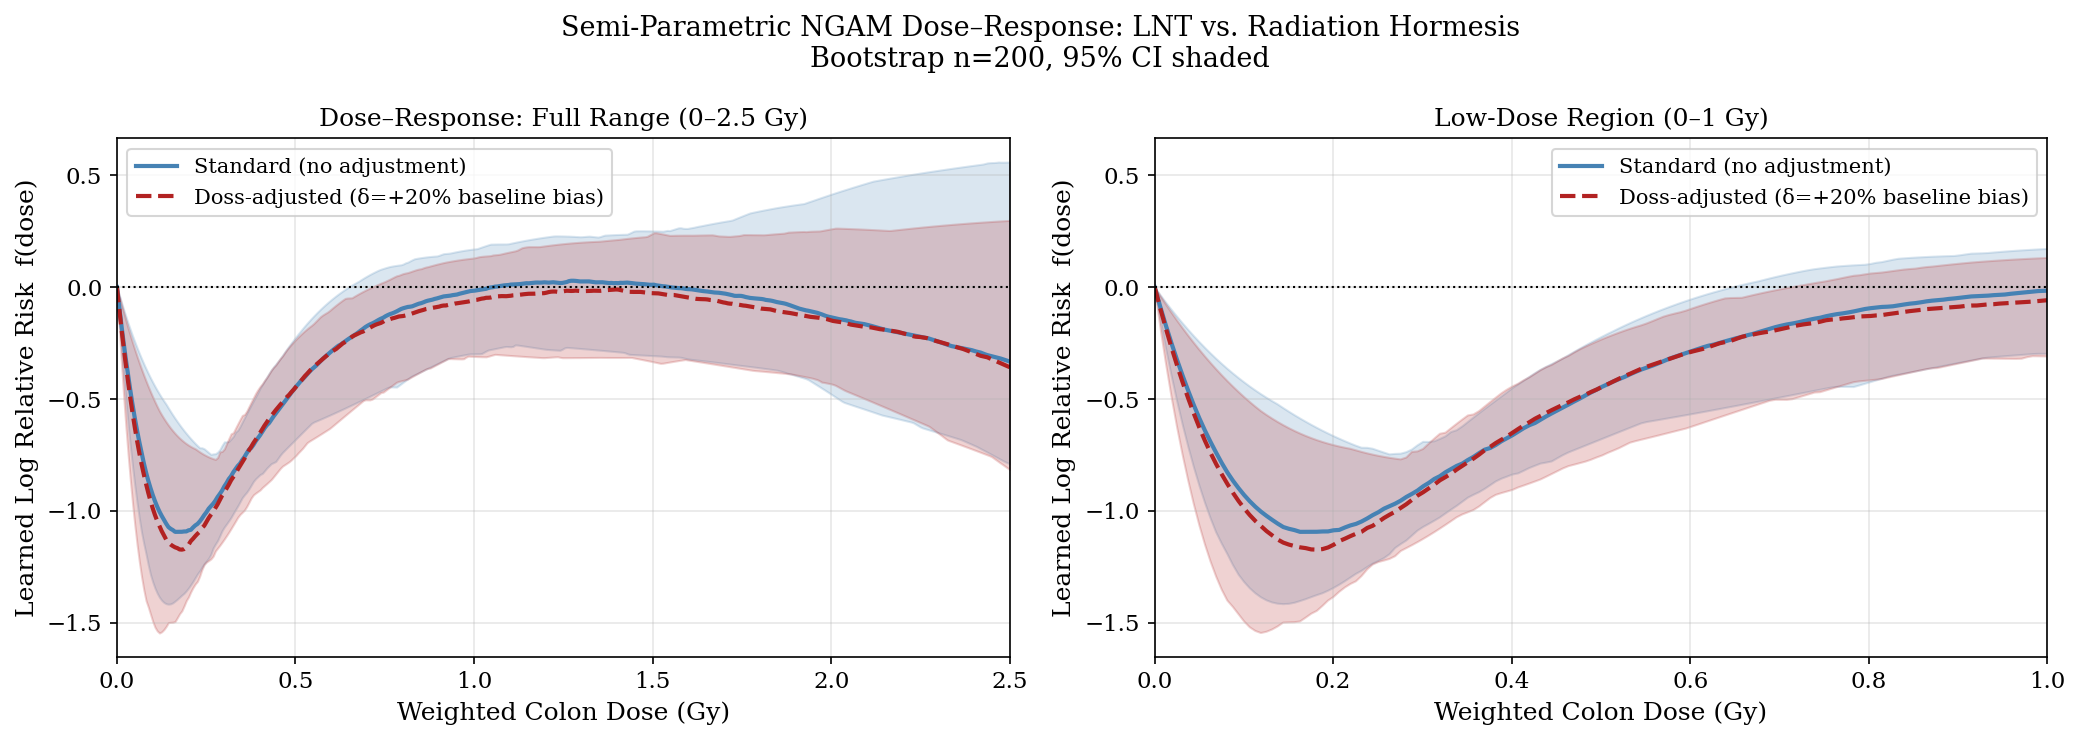

In [19]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import json
from tqdm import tqdm

# ============================================================
# 0. Global Setup
# ============================================================
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    print(f"Hardware: NVIDIA GPU ({torch.cuda.get_device_name(0)})")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
    print("CPU : AMD Ryzen")
else:
    DEVICE = torch.device("cpu")
    print("Hardware: CPU")

os.makedirs("trained_models", exist_ok=True)

# ============================================================
# 1. Semi-Parametric NGAM Architecture
# ============================================================
class PoissonNGAM(nn.Module):
    def __init__(self, num_linear_features: int):
        super().__init__()
        self.linear_branch = nn.Linear(num_linear_features, 1, bias=True)
        self.dose_linear_trend = nn.Linear(1, 1, bias=False)
        self.dose_mlp = nn.Sequential(
            nn.Linear(1, 16),
            nn.SiLU(),          
            nn.Linear(16, 16),
            nn.SiLU(),
            nn.Linear(16, 1),
        )

    def forward(self, x_lin, x_dose, offset):
        lin_effect = self.linear_branch(x_lin) 
        linear_dose_effect = self.dose_linear_trend(x_dose)
        raw_mlp = self.dose_mlp(x_dose)
        zero_mlp = self.dose_mlp(torch.zeros_like(x_dose))
        neural_dose_effect = raw_mlp - zero_mlp
        total_dose_effect = linear_dose_effect + neural_dose_effect
        log_lambda = lin_effect + total_dose_effect + offset
        return torch.exp(log_lambda)

    def get_dose_shape(self, x_dose):
        lin_eff = self.dose_linear_trend(x_dose)
        nn_eff = self.dose_mlp(x_dose) - self.dose_mlp(torch.zeros_like(x_dose))
        return lin_eff + nn_eff


# ============================================================
# 2. Data Preparation
# ============================================================
def preprocess_data(df: pd.DataFrame):
    df = df.copy()
    df["log_age"]  = np.log(df["age"])
    df["log_agex"] = np.log(df["agex"])
    df["log_pyr"]  = np.log(df["pyr"])

    cat_cols = ["city", "sex", "ctime", "gd3", "ahs"]
    df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

    dummy_cols = [c for c in df.columns if any(c.startswith(f"{b}_") for b in cat_cols)]
    for col in dummy_cols:
        df[col] = df[col].astype(np.float32)

    linear_features = dummy_cols + ["log_age", "log_agex"]

    X_lin  = df[linear_features].values.astype(np.float32)
    X_dose = df[["dose"]].values.astype(np.float32)
    Y      = df["solid"].values.astype(np.float32)
    Offset = df["log_pyr"].values.astype(np.float32)

    t_X_lin  = torch.tensor(X_lin,   device=DEVICE)
    t_X_dose = torch.tensor(X_dose,  device=DEVICE)
    t_Y      = torch.tensor(Y,       device=DEVICE).unsqueeze(1)
    t_Offset = torch.tensor(Offset,  device=DEVICE).unsqueeze(1)

    return t_X_lin, t_X_dose, t_Y, t_Offset, len(linear_features)


# ============================================================
# 3. Bootstrap Training Loop
# ============================================================
def bootstrap_ngam(
    t_X_lin, t_X_dose, t_Y, t_Offset, num_lin_features,
    baseline_bias_delta=0.0, n_bootstraps=50, epochs=200,
    lr=0.01, weight_decay=1e-4, patience=15, min_delta=1e-5,
    dose_grid_max=1.5, run_name="standard"
):
    N = t_X_lin.shape[0]
    n_grid = 400
    dose_grid = torch.linspace(0.0, dose_grid_max, n_grid, device=DEVICE).unsqueeze(1)
    loss_fn = nn.PoissonNLLLoss(log_input=False, full=True)
    all_shapes = []

    print(f"\n{'='*65}\n Run : '{run_name}' | delta={baseline_bias_delta*100:.0f}% | "
          f"n_boot={n_bootstraps} | epochs={epochs}\n{'='*65}")

    for b in tqdm(range(n_bootstraps), desc=run_name):
        idx      = torch.randint(0, N, (N,), device=DEVICE)
        b_X_lin  = t_X_lin[idx]
        b_X_dose = t_X_dose[idx]
        b_Y      = t_Y[idx]
        b_Offset = t_Offset[idx].clone()

        if baseline_bias_delta > 0.0:
            b_Offset = b_Offset + float(np.log(1.0 + baseline_bias_delta))

        model = PoissonNGAM(num_lin_features).to(DEVICE)
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=lr/100)

        best_loss = float("inf")
        patience_count = 0

        model.train()
        for _ in range(epochs):
            optimizer.zero_grad()
            preds = model(b_X_lin, b_X_dose, b_Offset)
            loss  = loss_fn(preds, b_Y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()
            scheduler.step()

            val = loss.item()
            if best_loss - val > min_delta:
                best_loss = val
                patience_count = 0
            else:
                patience_count += 1
            if patience_count >= patience:
                break

        model.eval()
        with torch.no_grad():
            shape = model.get_dose_shape(dose_grid).cpu().numpy().flatten()
        all_shapes.append(shape)

        torch.save(model.state_dict(), os.path.join("trained_models", f"ngam_{run_name}_boot_{b:03d}.pth"))

    return np.array(all_shapes), dose_grid.cpu().numpy().flatten()


# ============================================================
# 4. Main Execution & Auto-JSON
# ============================================================
if __name__ == "__main__":
    print("Loading LSS-14 data ...")
    df = pd.read_csv("Data/lss14.csv") 

    df["dose"] = df["colon10"] / 1000.0
    df = df[(df["dose"] >= 0.0) & (df["dose"] <= 2.5) & (df["pyr"] > 0.0) & (df["age"] > 0.0) & (df["agex"] > 0.0)].copy()
    
    max_dose_in_data = df["dose"].max()
    print(f"Maximum dose in dataset: {max_dose_in_data:.4f} Gy")

    t_X_lin, t_X_dose, t_Y, t_Offset, num_lin_features = preprocess_data(df)

    N_BOOTSTRAPS  = 200
    EPOCHS        = 400
    DOSE_GRID_MAX = 2.5
    DELTA_DOSS    = 0.20

    shapes_std, dose_grid = bootstrap_ngam(
        t_X_lin, t_X_dose, t_Y, t_Offset, num_lin_features,
        baseline_bias_delta = 0.0, n_bootstraps=N_BOOTSTRAPS, epochs=EPOCHS,
        dose_grid_max=DOSE_GRID_MAX, run_name="standard_0pct"
    )

    shapes_doss, _ = bootstrap_ngam(
        t_X_lin, t_X_dose, t_Y, t_Offset, num_lin_features,
        baseline_bias_delta = DELTA_DOSS, n_bootstraps=N_BOOTSTRAPS, epochs=EPOCHS,
        dose_grid_max=DOSE_GRID_MAX, run_name=f"doss_adjusted_{int(DELTA_DOSS*100)}pct"
    )

    def boot_summary(shapes, q=(2.5, 50, 97.5)):
        return [np.percentile(shapes, qi, axis=0) for qi in q]

    std_lo,  std_med,  std_hi  = boot_summary(shapes_std)
    doss_lo, doss_med, doss_hi = boot_summary(shapes_doss)

    np.savez("Unfrozen_1_5Gy_npz/ngam_unfrozen_1_5gy.npz", dose_grid=dose_grid, shapes_std=shapes_std, shapes_doss=shapes_doss)
    
    # Plotting
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

    # Adjusted title for the full range chart
    for ax, xlim, title in zip(axes, [DOSE_GRID_MAX, 1.0], ["Dose–Response: Full Range (0–2.5 Gy)", "Low-Dose Region (0–1 Gy)"]):
        ax.plot(dose_grid, std_med,  color="steelblue",  lw=2, label="Standard (no adjustment)")
        ax.fill_between(dose_grid, std_lo,  std_hi,  color="steelblue",  alpha=0.20)
        ax.plot(dose_grid, doss_med, color="firebrick", lw=2, linestyle="--", label=f"Doss-adjusted (δ=+{int(DELTA_DOSS*100)}% baseline bias)")
        ax.fill_between(dose_grid, doss_lo, doss_hi, color="firebrick", alpha=0.20)
        ax.axhline(0, color="black", lw=1.0, linestyle=":")
        ax.set_xlabel("Weighted Colon Dose (Gy)", fontsize=12)
        ax.set_ylabel("Learned Log Relative Risk  f(dose)", fontsize=12)
        ax.set_title(title, fontsize=12)
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.set_xlim(0, xlim)

    fig.suptitle(f"Semi-Parametric NGAM Dose–Response: LNT vs. Radiation Hormesis\nBootstrap n={N_BOOTSTRAPS}, 95% CI shaded", fontsize=13)
    plt.tight_layout()
    plt.savefig("all charts/ngam_unfrozen_1_5gy.pdf", dpi=300)
    plt.savefig("PDF/ngam_unfrozen_1_5gy.png", dpi=300)
    
    # ==========================================
    # Auto-Extract JSON
    # ==========================================
   
    target_doses = [0.0, 0.05, 0.1, 0.15, 0.2, 0.3, 0.5, 0.75, 1.0, 1.5, 2.0, 2.5]
    
    summary_results = {}
    for dose in target_doses:
        summary_results[f"{dose:.2f}_Gy"] = {
            "Standard_f_dose": {
                "Median": round(float(np.interp(dose, dose_grid, std_med)), 4),
                "95_CI": [
                    round(float(np.interp(dose, dose_grid, std_lo)), 4), 
                    round(float(np.interp(dose, dose_grid, std_hi)), 4)
                ]
            },
            "Doss_Adjusted_f_dose": {
                "Median": round(float(np.interp(dose, dose_grid, doss_med)), 4),
                "95_CI": [
                    round(float(np.interp(dose, dose_grid, doss_lo)), 4), 
                    round(float(np.interp(dose, dose_grid, doss_hi)), 4)
                ]
            }
        }

    print("\n\n--- AUTO-GENERATED JSON OUTPUT ---")
    print(json.dumps(summary_results, indent=2))
    print("----------------------------------\n")

Base NGAM with frozen Linear branch at various Bias level

Hardware: NVIDIA GPU (NVIDIA GeForce GTX 1650 Ti)
Loading LSS-14 data...
Rows after cleaning : 53782
Maximum dose in data: 3.7200 Gy
Linear features (18): ['intercept', 'city_2', 'sex_2', 'ctime_2', 'ctime_3', 'ctime_4', 'ctime_5', 'ctime_6', 'ctime_7', 'ctime_8', 'ctime_9', 'ctime_10', 'ctime_11', 'gd3_2', 'ahs_1', 'ahs_2', 'log_age', 'log_agex']

 Run  : 'bias_00pct'
 Bias : +0%  (log correction = 0.000000)
 Boot : 200  |  Epochs : 400

Stage 1a: Fitting linear branch on full data (warm start)...
  Done. NLL = 11552.7609


bias_00pct: 100%|██████████| 200/200 [02:39<00:00,  1.25it/s]



 Run  : 'bias_10pct'
 Bias : +10%  (log correction = 0.095310)
 Boot : 200  |  Epochs : 400

Stage 1a: Fitting linear branch on full data (warm start)...
  Done. NLL = 11552.7609


bias_10pct: 100%|██████████| 200/200 [04:03<00:00,  1.22s/it]



 Run  : 'bias_20pct'
 Bias : +20%  (log correction = 0.182322)
 Boot : 200  |  Epochs : 400

Stage 1a: Fitting linear branch on full data (warm start)...
  Done. NLL = 11552.7609


bias_20pct: 100%|██████████| 200/200 [05:00<00:00,  1.50s/it]



 Run  : 'bias_30pct'
 Bias : +30%  (log correction = 0.262364)
 Boot : 200  |  Epochs : 400

Stage 1a: Fitting linear branch on full data (warm start)...
  Done. NLL = 11552.7609


bias_30pct: 100%|██████████| 200/200 [06:16<00:00,  1.88s/it]



Plots saved.


--- STAGED NGAM BIAS SENSITIVITY JSON ---
{
  "bias_00pct": {
    "_description": "No correction. Standard analysis.",
    "dose_response": {
      "0.00_Gy": {
        "f_dose_log_RR": {
          "Median": 0.0,
          "95_CI": [
            0.0,
            0.0
          ]
        }
      },
      "0.05_Gy": {
        "f_dose_log_RR": {
          "Median": 0.0091,
          "95_CI": [
            -0.0018,
            0.0163
          ]
        }
      },
      "0.10_Gy": {
        "f_dose_log_RR": {
          "Median": 0.0184,
          "95_CI": [
            -0.0027,
            0.0325
          ]
        }
      },
      "0.15_Gy": {
        "f_dose_log_RR": {
          "Median": 0.028,
          "95_CI": [
            -0.0025,
            0.0485
          ]
        }
      },
      "0.20_Gy": {
        "f_dose_log_RR": {
          "Median": 0.0375,
          "95_CI": [
            -0.0011,
            0.0644
          ]
        }
      },
      "0.30_Gy": {
    

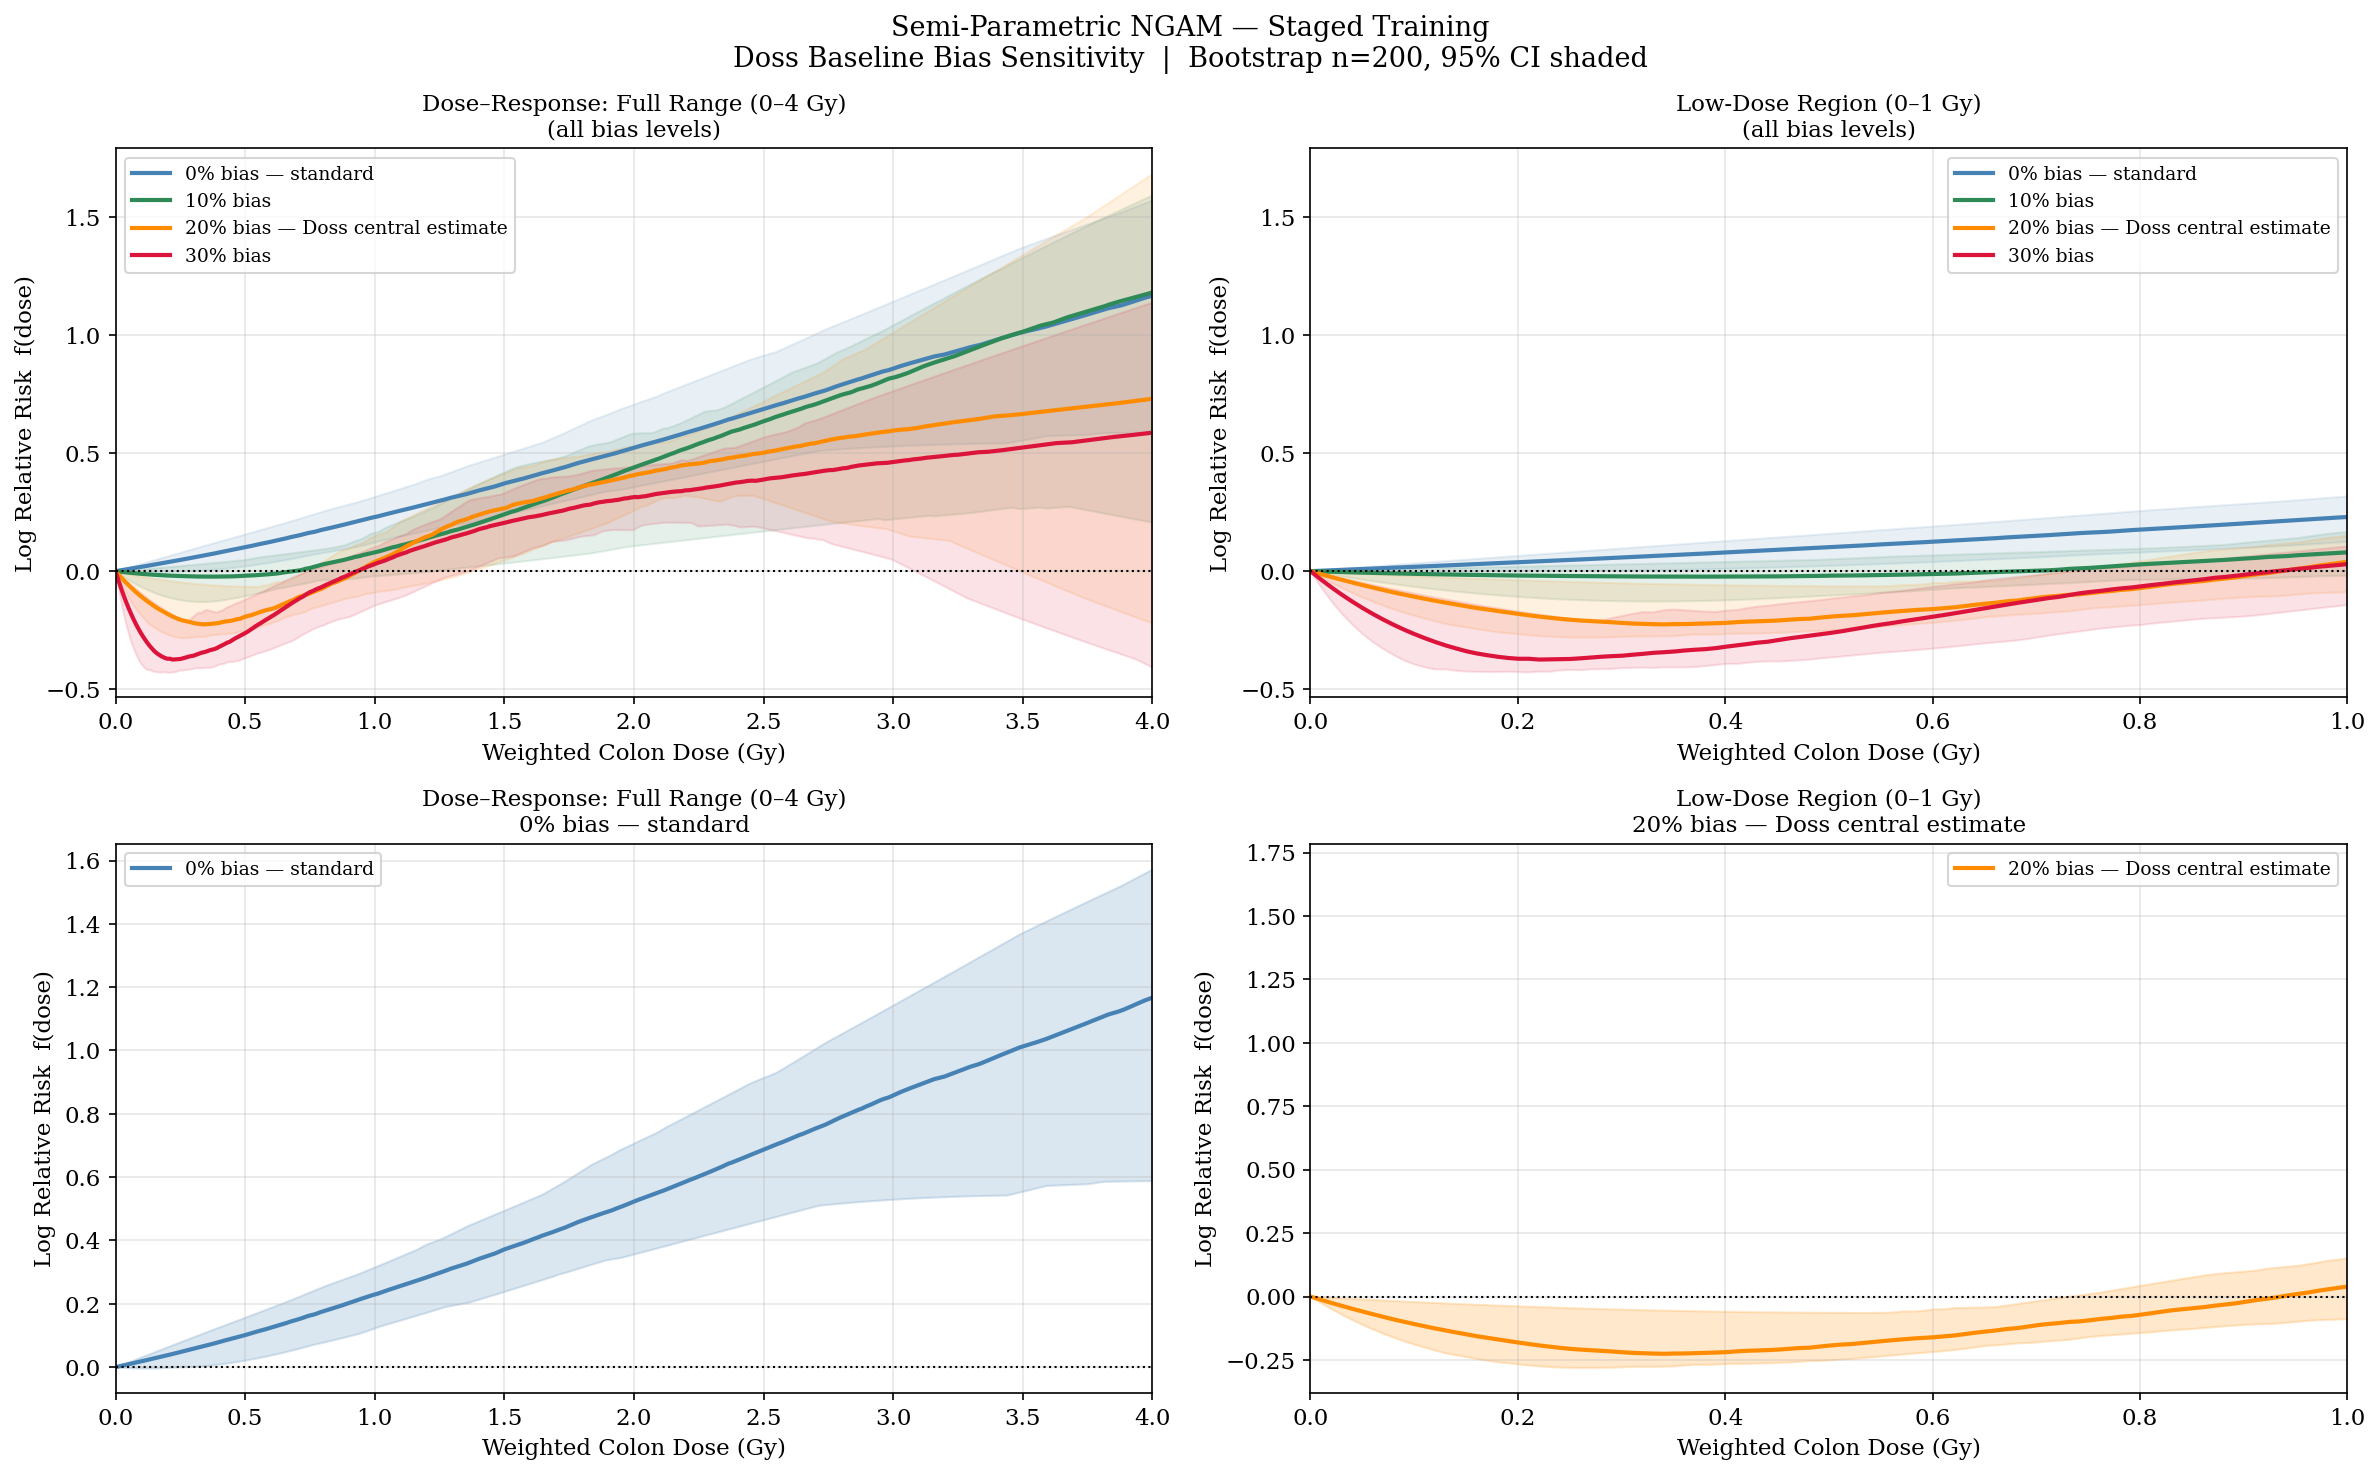

In [ ]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import json
from scipy.optimize import minimize
from scipy.special import xlogy
from tqdm import tqdm

# ============================================================
# 0. Global Setup
# ============================================================
torch.manual_seed(42)
np.random.seed(42)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    print(f"Hardware: NVIDIA GPU ({torch.cuda.get_device_name(0)})")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
    print("Hardware: Apple Silicon (MPS)")
else:
    DEVICE = torch.device("cpu")
    print("Hardware: CPU")

os.makedirs("trained_models", exist_ok=True)


# ============================================================
# 1. Data Preparation
# ============================================================
def preprocess_data(df: pd.DataFrame):
    """
    Returns everything needed for both stages.
    Dose is kept separate and is NEVER passed to the linear branch.
    """
    df = df.copy()
    df["log_age"]  = np.log(df["age"])
    df["log_agex"] = np.log(df["agex"])
    df["log_pyr"]  = np.log(df["pyr"])

    cat_cols = ["city", "sex", "ctime", "gd3", "ahs"]
    df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

    dummy_cols = [c for c in df.columns
                  if any(c.startswith(f"{b}_") for b in cat_cols)]
    for col in dummy_cols:
        df[col] = df[col].astype(np.float32)

    linear_features = dummy_cols + ["log_age", "log_agex"]

    X_lin_np  = np.column_stack([
        np.ones(len(df)),
        df[linear_features].values.astype(np.float64)
    ])
    Y_np      = df["solid"].values.astype(np.float64)
    Offset_np = df["log_pyr"].values.astype(np.float64)

    X_dose_t = torch.tensor(
        df[["dose"]].values.astype(np.float32), device=DEVICE)
    Y_t      = torch.tensor(Y_np, device=DEVICE).float().unsqueeze(1)
    Offset_t = torch.tensor(Offset_np, device=DEVICE).float().unsqueeze(1)

    feature_names = ["intercept"] + linear_features

    return (
        X_lin_np, Y_np, Offset_np,
        X_dose_t, Y_t, Offset_t,
        feature_names
    )


# ============================================================
# 2. Stage 1 — Linear Branch (Poisson GLM via scipy)
# ============================================================
def poisson_negloglik(beta, X, Y, Offset):
    mu = np.exp(np.clip(X @ beta + Offset, -30, 30))
    return np.sum(mu - xlogy(Y, mu))

def poisson_gradient(beta, X, Y, Offset):
    mu = np.exp(np.clip(X @ beta + Offset, -30, 30))
    return X.T @ (mu - Y)

def fit_linear_branch(X, Y, Offset, init_beta=None):
    p = X.shape[1]
    if init_beta is None:
        init_beta = np.zeros(p)
    result = minimize(
        poisson_negloglik, init_beta,
        args=(X, Y, Offset),
        jac=poisson_gradient,
        method="L-BFGS-B",
        options={"maxiter": 1000, "ftol": 1e-12, "gtol": 1e-8}
    )
    return result.x, result.success


# ============================================================
# 3. Stage 2 — Neural Dose Branch (PyTorch MLP)
# ============================================================
class DoseMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.dose_linear_trend = nn.Linear(1, 1, bias=False)
        self.dose_mlp = nn.Sequential(
            nn.Linear(1, 16),
            nn.SiLU(),
            nn.Linear(16, 16),
            nn.SiLU(),
            nn.Linear(16, 1),
        )

    def forward(self, x_dose, offset):
        """
        offset = log_pyr + linear_branch_log_rate + bias_correction
        Zero-centred: f(0 Gy) = 0 by construction.
        """
        linear_dose_effect = self.dose_linear_trend(x_dose)
        raw_mlp            = self.dose_mlp(x_dose)
        zero_mlp           = self.dose_mlp(torch.zeros_like(x_dose))
        dose_effect        = linear_dose_effect + (raw_mlp - zero_mlp)
        log_lambda         = dose_effect + offset
        return torch.exp(log_lambda)

    def get_dose_shape(self, x_dose):
        """Returns the learned log relative risk curve f(dose)."""
        lin_eff = self.dose_linear_trend(x_dose)
        nn_eff  = self.dose_mlp(x_dose) - self.dose_mlp(torch.zeros_like(x_dose))
        return lin_eff + nn_eff


# ============================================================
# 4. Bootstrap — Staged Training Loop
# ============================================================
def bootstrap_staged(
    X_lin_np, Y_np, Offset_np,
    X_dose_t, Y_t, Offset_t,
    baseline_bias_pct=0.0,
    n_bootstraps=200, epochs=400,
    lr=0.01, weight_decay=1e-4,
    patience=15, min_delta=1e-5,
    dose_grid_max=4.0,
    run_name="staged"
):
    N      = len(Y_np)
    n_grid = 400

    bias_log_correction = float(np.log(1.0 + baseline_bias_pct / 100.0))

    dose_grid  = torch.linspace(
        0.0, dose_grid_max, n_grid, device=DEVICE).unsqueeze(1)
    loss_fn    = nn.PoissonNLLLoss(log_input=False, full=True)
    all_shapes = []

    print(f"\n{'='*65}")
    print(f" Run  : '{run_name}'")
    print(f" Bias : +{baseline_bias_pct:.0f}%  "
          f"(log correction = {bias_log_correction:.6f})")
    print(f" Boot : {n_bootstraps}  |  Epochs : {epochs}")
    print(f"{'='*65}")

    print("\nStage 1a: Fitting linear branch on full data (warm start)...")
    beta_full, ok = fit_linear_branch(X_lin_np, Y_np, Offset_np)
    if not ok:
        print("  WARNING: Full-data linear fit did not fully converge")
    print(f"  Done. NLL = "
          f"{poisson_negloglik(beta_full, X_lin_np, Y_np, Offset_np):.4f}")

    for b in tqdm(range(n_bootstraps), desc=run_name):
        idx = np.random.randint(0, N, N)

        # ---- Stage 1: Linear branch — no dose, no bias ----
        b_X_lin  = X_lin_np[idx]
        b_Y_np   = Y_np[idx]
        b_Off_np = Offset_np[idx]

        beta_b, _ = fit_linear_branch(
            b_X_lin, b_Y_np, b_Off_np,
            init_beta=beta_full.copy())

        lin_log_rate_b = (b_X_lin @ beta_b).astype(np.float32)

        # ---- Stage 2: Neural dose branch ----
        b_X_dose = X_dose_t[idx]
        b_Y_t    = Y_t[idx]

        b_Off_torch = torch.tensor(
            b_Off_np.astype(np.float32), device=DEVICE).unsqueeze(1)
        b_lin_torch = torch.tensor(
            lin_log_rate_b, device=DEVICE).unsqueeze(1)

        b_combined_offset = (
            b_Off_torch
            + b_lin_torch
            + bias_log_correction      
        )

        model     = DoseMLP().to(DEVICE)
        optimizer = optim.Adam(
            model.parameters(), lr=lr, weight_decay=weight_decay)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=epochs, eta_min=lr / 100)

        best_loss      = float("inf")
        patience_count = 0

        model.train()
        for _ in range(epochs):
            optimizer.zero_grad()
            preds = model(b_X_dose, b_combined_offset)
            loss  = loss_fn(preds, b_Y_t)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()
            scheduler.step()

            val = loss.item()
            if best_loss - val > min_delta:
                best_loss      = val
                patience_count = 0
            else:
                patience_count += 1
            if patience_count >= patience:
                break

        model.eval()
        with torch.no_grad():
            shape = model.get_dose_shape(dose_grid).cpu().numpy().flatten()
        all_shapes.append(shape)

        torch.save(
            model.state_dict(),
            os.path.join(
                "trained_models",
                f"dose_mlp_{run_name}_boot_{b:03d}.pth"))

    return np.array(all_shapes), dose_grid.cpu().numpy().flatten()


# ============================================================
# 5. Main Execution
# ============================================================
if __name__ == "__main__":

    print("Loading LSS-14 data...")
    df = pd.read_csv("Data/lss14.csv")

    df["dose"] = df["colon10"] / 1000.0
    df = df[
        (df["dose"] >= 0.0) &
        (df["pyr"]  >  0.0) &
        (df["age"]  >  0.0) &
        (df["agex"] >  0.0)
    ].copy()

    print(f"Rows after cleaning : {len(df)}")
    print(f"Maximum dose in data: {df['dose'].max():.4f} Gy")

    (X_lin_np, Y_np, Offset_np,
     X_dose_t, Y_t, Offset_t,
     feature_names) = preprocess_data(df)

    print(f"Linear features ({len(feature_names)}): {feature_names}")

    N_BOOTSTRAPS  = 200
    EPOCHS        = 400
    DOSE_GRID_MAX = 4.0

    # ----------------------------------------------------------
    # Bias levels
    # ----------------------------------------------------------
    BIAS_LEVELS = [0, 10, 20, 30]
    COLOURS = {
        0:  ("steelblue",  "0% bias — standard"),
        5:  ("lightsteelblue", "5% bias"),
        10: ("seagreen",   "10% bias"),
        20: ("darkorange", "20% bias — Doss central estimate"),
        30: ("crimson",    "30% bias"),
    }

    all_results = {}   

    for bias_pct in BIAS_LEVELS:
        run_label = f"bias_{bias_pct:02d}pct"

        shapes, dose_grid = bootstrap_staged(
            X_lin_np, Y_np, Offset_np,
            X_dose_t, Y_t, Offset_t,
            baseline_bias_pct = bias_pct,
            n_bootstraps      = N_BOOTSTRAPS,
            epochs            = EPOCHS,
            dose_grid_max     = DOSE_GRID_MAX,
            run_name          = run_label
        )

        lo  = np.percentile(shapes,  2.5, axis=0)
        med = np.percentile(shapes, 50.0, axis=0)
        hi  = np.percentile(shapes, 97.5, axis=0)

        all_results[bias_pct] = (lo, med, hi, dose_grid)

        np.savez(
            f"Frozen_4Gy_npz/ngam_frozen_4gy{run_label}.npz",
            dose_grid=dose_grid,
            shapes=shapes,
            bias_pct=np.array([bias_pct])
        )

    # ----------------------------------------------------------
    # Plotting
    # ----------------------------------------------------------
    fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=False)

    xlims  = [DOSE_GRID_MAX, 1.0]
    titles = [
        "Dose–Response: Full Range (0–4 Gy)",
        "Low-Dose Region (0–1 Gy)"
    ]

    for col, (xlim, title) in enumerate(zip(xlims, titles)):
        for row in range(2):
            ax = axes[row][col]

            if row == 0:
                for bias_pct in BIAS_LEVELS:
                    lo, med, hi, dg = all_results[bias_pct]
                    colour, label   = COLOURS[bias_pct]
                    ax.plot(dg, med,
                            color=colour, lw=2, label=label)
                    ax.fill_between(dg, lo, hi,
                                    color=colour, alpha=0.12)
                ax.legend(fontsize=9)
                ax.set_title(f"{title}\n(all bias levels)", fontsize=11)

            else:
                bias_pct = [0, 20][col]
                lo, med, hi, dg = all_results[bias_pct]
                colour, label   = COLOURS[bias_pct]
                ax.plot(dg, med, color=colour, lw=2, label=label)
                ax.fill_between(dg, lo, hi, color=colour, alpha=0.20)
                ax.set_title(
                    f"{title}\n{label}", fontsize=11)
                ax.legend(fontsize=9)

            ax.axhline(0, color="black", lw=1.0, linestyle=":")
            ax.set_xlabel("Weighted Colon Dose (Gy)", fontsize=11)
            ax.set_ylabel("Log Relative Risk  f(dose)", fontsize=11)
            ax.grid(True, alpha=0.3)
            ax.set_xlim(0, xlim)

    fig.suptitle(
        f"Semi-Parametric NGAM — Staged Training\n"
        f"Doss Baseline Bias Sensitivity  |  "
        f"Bootstrap n={N_BOOTSTRAPS}, 95% CI shaded",
        fontsize=13)
    plt.tight_layout()
    plt.savefig("all charts/ngam_frozen_4gy.pdf", dpi=300)
    plt.savefig("PDF/ngam_frozen_4gy.png", dpi=300)
    print("\nPlots saved.")

    # ----------------------------------------------------------
    # JSON output — one block per bias level
    # ----------------------------------------------------------
    target_doses = [0.0, 0.05, 0.1, 0.15, 0.2, 0.3,
                    0.5, 0.75, 1.0, 1.5, 2.0, 3.0]

    summary = {}

    for bias_pct in BIAS_LEVELS:
        lo, med, hi, dg = all_results[bias_pct]
        block = {}
        for dose in target_doses:
            block[f"{dose:.2f}_Gy"] = {
                "f_dose_log_RR": {
                    "Median": round(float(np.interp(dose, dg, med)), 4),
                    "95_CI":  [
                        round(float(np.interp(dose, dg, lo)), 4),
                        round(float(np.interp(dose, dg, hi)), 4)
                    ]
                }
            }
        summary[f"bias_{bias_pct:02d}pct"] = {
            "_description": (
                f"+{bias_pct}% upward correction to demographic baseline. "
                "Implements the Doss (2013) hypothesis that the LSS "
                "lowest-dose group already has suppressed cancer rates "
                "due to hormesis, making the raw LSS baseline too low."
                if bias_pct > 0 else
                "No correction. Standard analysis."
            ),
            "dose_response": block
        }

    print("\n\n--- STAGED NGAM BIAS SENSITIVITY JSON ---")
    print(json.dumps(summary, indent=2))
    print("-----------------------------------------\n")

    with open("JSON Model Outputs/ngam_frozen_4gy.json", "w") as f:
        json.dump(summary, f, indent=2)
    print("JSON saved to JSON Model Outputs/ngam_frozen_4gy.json")

Visualization

In [18]:
"""
visualise_results.py
====================
Run this AFTER ngam_staged.py has completed.

Expects in the working directory:
  - Data/lss14.csv
  - ngam_staged_bias_00pct.npz
  - ngam_staged_bias_10pct.npz
  - ngam_staged_bias_20pct.npz
  - ngam_staged_bias_30pct.npz

Produces:
  fig1_linear_branch_coefficients.pdf/.png
  fig2_linear_branch_observed_vs_predicted.pdf/.png
  fig3_linear_branch_residuals_by_dose.pdf/.png
  fig4_dose_response_all_bias_levels.pdf/.png
  fig5_dose_response_lowdose_zoom.pdf/.png
  fig6_hormetic_dip_annotation.pdf/.png
  fig7_bootstrap_uncertainty_ribbon.pdf/.png
  fig8_bias_sensitivity_summary.pdf/.png
  publication_summary.json
"""

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch
from scipy.optimize import minimize
from scipy.special import xlogy

# ============================================================
# 0. Style
# ============================================================
plt.rcParams.update({
    "font.family":      "serif",
    "font.size":        11,
    "axes.titlesize":   12,
    "axes.labelsize":   11,
    "legend.fontsize":  9,
    "figure.dpi":       150,
})

COLOURS = {
    0:  ("steelblue",   "0% bias — standard (no correction)"),
    10: ("seagreen",    "10% bias — conservative"),
    20: ("darkorange",  "20% bias — Doss (2013) central estimate"),
    30: ("crimson",     "30% bias — upper sensitivity bound"),
}

os.makedirs("figures", exist_ok=True)


# ============================================================
# 1. Rebuild linear branch on full data
#    (same logic as training script — reproducible via seed)
# ============================================================
def poisson_negloglik(beta, X, Y, Offset):
    mu = np.exp(np.clip(X @ beta + Offset, -30, 30))
    return np.sum(mu - xlogy(Y, mu))

def poisson_gradient(beta, X, Y, Offset):
    mu = np.exp(np.clip(X @ beta + Offset, -30, 30))
    return X.T @ (mu - Y)

def fit_linear_branch(X, Y, Offset, init_beta=None):
    p = X.shape[1]
    if init_beta is None:
        init_beta = np.zeros(p)
    result = minimize(
        poisson_negloglik, init_beta,
        args=(X, Y, Offset),
        jac=poisson_gradient,
        method="L-BFGS-B",
        options={"maxiter": 1000, "ftol": 1e-12, "gtol": 1e-8}
    )
    return result.x, result.success

def load_data_and_fit():
    np.random.seed(42)
    print("Loading LSS-14 data and fitting linear branch...")

    df = pd.read_csv("Data/lss14.csv")
    df["dose"] = df["colon10"] / 1000.0
    df = df[
        (df["dose"] >= 0.0) &
        (df["pyr"]  >  0.0) &
        (df["age"]  >  0.0) &
        (df["agex"] >  0.0)
    ].copy()

    df["log_age"]  = np.log(df["age"])
    df["log_agex"] = np.log(df["agex"])
    df["log_pyr"]  = np.log(df["pyr"])

    cat_cols   = ["city", "sex", "ctime", "gd3", "ahs"]
    df_dummies = pd.get_dummies(df, columns=cat_cols, drop_first=True)
    dummy_cols = [c for c in df_dummies.columns
                  if any(c.startswith(f"{b}_") for b in cat_cols)]

    linear_features = dummy_cols + ["log_age", "log_agex"]
    feature_names   = ["intercept"] + linear_features

    X_lin  = np.column_stack([
        np.ones(len(df_dummies)),
        df_dummies[linear_features].values.astype(np.float64)
    ])
    Y      = df_dummies["solid"].values.astype(np.float64)
    Offset = df_dummies["log_pyr"].values.astype(np.float64)

    beta, ok = fit_linear_branch(X_lin, Y, Offset)
    if not ok:
        print("  WARNING: linear branch did not fully converge")

    mu_pred = np.exp(np.clip(X_lin @ beta + Offset, -30, 30))

    # Attach predictions and dose category back to the original df
    df["predicted"] = mu_pred
    df["observed"]  = Y
    df["pearson_resid"] = (Y - mu_pred) / np.sqrt(np.maximum(mu_pred, 1e-8))

    return df, beta, feature_names, X_lin, Y, Offset


# ============================================================
# 2. Load bootstrap results
# ============================================================
def load_bootstrap_results():
    results = {}
    for bias_pct in [0, 10, 20, 30]:
        fname = f"Frozen_4Gy_npz/ngam_frozen_4gybias_{bias_pct:02d}pct.npz"
        data  = np.load(fname)
        shapes    = data["shapes"]       # (n_boot, n_grid)
        dose_grid = data["dose_grid"]    # (n_grid,)
        lo  = np.percentile(shapes,  2.5, axis=0)
        med = np.percentile(shapes, 50.0, axis=0)
        hi  = np.percentile(shapes, 97.5, axis=0)
        results[bias_pct] = {
            "lo": lo, "med": med, "hi": hi,
            "dose_grid": dose_grid,
            "shapes": shapes
        }
        print(f"  Loaded bias={bias_pct}%  shapes={shapes.shape}")
    return results


# ============================================================
# FIG 1 — Linear Branch Coefficients
#
# Purpose: Show the baseline model is epidemiologically
#          valid before the neural branch ever runs.
#          Reviewers can compare to published RERF tables.
# ============================================================
def fig1_linear_coefficients(beta, feature_names):
    print("Plotting Fig 1: Linear branch coefficients...")

    # Select coefficients to display (skip intercept for clarity)
    names  = feature_names[1:]
    coefs  = beta[1:]
    rrs    = np.exp(coefs)

    # Clean display names
    clean = []
    for n in names:
        n = n.replace("_2", " (2 vs 1)").replace("_", " ")
        clean.append(n)

    # Sort by absolute coefficient magnitude
    order  = np.argsort(np.abs(coefs))[::-1]
    names_s = [clean[i] for i in order]
    coefs_s = coefs[order]
    rrs_s   = rrs[order]

    fig, axes = plt.subplots(1, 2, figsize=(14, 7))

    # Left: log-scale coefficients (forest-plot style)
    ax = axes[0]
    y  = np.arange(len(names_s))
    ax.barh(y, coefs_s,
            color=["steelblue" if c > 0 else "crimson" for c in coefs_s],
            edgecolor="white", height=0.6, alpha=0.85)
    ax.axvline(0, color="black", lw=1.2, linestyle="--")
    ax.set_yticks(y)
    ax.set_yticklabels(names_s, fontsize=8)
    ax.set_xlabel("Log-Scale Coefficient  (log rate ratio)", fontsize=10)
    ax.set_title("Linear Branch Coefficients\n(log-scale)", fontsize=11)
    ax.grid(axis="x", alpha=0.3)

    # Right: rate ratios on natural scale
    ax2 = axes[1]
    ax2.barh(y, rrs_s,
             color=["steelblue" if r > 1 else "crimson" for r in rrs_s],
             edgecolor="white", height=0.6, alpha=0.85)
    ax2.axvline(1.0, color="black", lw=1.2, linestyle="--")
    ax2.set_yticks(y)
    ax2.set_yticklabels(names_s, fontsize=8)
    ax2.set_xlabel("Rate Ratio  exp(coef)", fontsize=10)
    ax2.set_title("Linear Branch Rate Ratios\n(natural scale)", fontsize=11)
    ax2.grid(axis="x", alpha=0.3)

    fig.suptitle(
        "Fig 1 — Linear Branch (Demographic Baseline)\n"
        "Poisson GLM fitted without dose  |  LSS-14",
        fontsize=12, y=1.01)
    plt.tight_layout()
    for ext in ["pdf", "png"]:
        plt.savefig(f"figures/fig1_linear_branch_coefficients.{ext}",
                    dpi=300, bbox_inches="tight")
    plt.close()
    print("  Saved fig1.")


# ============================================================
# FIG 2 — Linear Branch: Observed vs Predicted by Dose Category
#
# Purpose: The critical validation.  Shows the linear branch
#          systematically underpredicts high-dose groups —
#          proving the dose signal was NOT absorbed by the
#          demographic covariates and is genuinely available
#          for the neural branch to learn.
# ============================================================
def fig2_obs_vs_pred_by_dose(df):
    print("Plotting Fig 2: Observed vs predicted by dose category...")

    dg = (df.groupby("dosecat")[["observed", "predicted"]]
            .sum().reset_index())
    dg["obs_pred_ratio"] = dg["observed"] / dg["predicted"]
    dg["dose_label"]     = dg["dosecat"].astype(str)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: grouped bar — observed vs predicted counts
    ax   = axes[0]
    x    = np.arange(len(dg))
    w    = 0.35
    ax.bar(x - w/2, dg["observed"],  width=w, label="Observed",
           color="steelblue", alpha=0.85, edgecolor="white")
    ax.bar(x + w/2, dg["predicted"], width=w, label="Predicted (linear only)",
           color="darkorange", alpha=0.85, edgecolor="white")
    ax.set_xticks(x)
    ax.set_xticklabels(dg["dose_label"], fontsize=8)
    ax.set_xlabel("Dose Category", fontsize=10)
    ax.set_ylabel("Solid Cancer Cases", fontsize=10)
    ax.set_title("Observed vs Predicted Solid Cancers\nby Dose Category", fontsize=11)
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

    # Right: obs/pred ratio — departure from 1.0 is the dose signal
    ax2 = axes[1]
    colours_bar = ["crimson" if r > 1.05 else
                   "seagreen" if r < 0.95 else
                   "grey" for r in dg["obs_pred_ratio"]]
    ax2.bar(x, dg["obs_pred_ratio"], color=colours_bar,
            alpha=0.85, edgecolor="white")
    ax2.axhline(1.0, color="black", lw=1.5, linestyle="--",
                label="Perfect prediction (ratio = 1.0)")
    ax2.set_xticks(x)
    ax2.set_xticklabels(dg["dose_label"], fontsize=8)
    ax2.set_xlabel("Dose Category", fontsize=10)
    ax2.set_ylabel("Observed / Predicted Ratio", fontsize=10)
    ax2.set_title(
        "Obs/Pred Ratio by Dose Category\n"
        "Rising ratio = dose signal available for neural branch",
        fontsize=11)
    ax2.legend()
    ax2.grid(axis="y", alpha=0.3)

    fig.suptitle(
        "Fig 2 — Linear Branch Validation\n"
        "Dose was NOT an input — rising obs/pred confirms dose signal "
        "is preserved in residuals",
        fontsize=12, y=1.01)
    plt.tight_layout()
    for ext in ["pdf", "png"]:
        plt.savefig(f"figures/fig2_linear_branch_obs_vs_pred.{ext}",
                    dpi=300, bbox_inches="tight")
    plt.close()
    print("  Saved fig2.")


# ============================================================
# FIG 3 — Linear Branch: Pearson Residuals vs Dose
#
# Purpose: Directly shows the residual dose pattern the MLP
#          is trained to explain.  A positive trend confirms
#          radiation harm at high doses; a negative dip at
#          low doses would be consistent with hormesis before
#          any correction is applied.
# ============================================================
def fig3_residuals_vs_dose(df):
    print("Plotting Fig 3: Pearson residuals vs dose...")

    # Aggregate residuals and mean dose per dose category
    dg = df.groupby("dosecat").agg(
        mean_dose    = ("dose",         "mean"),
        sum_obs      = ("observed",     "sum"),
        sum_pred     = ("predicted",    "sum"),
    ).reset_index()
    dg["agg_resid"] = (dg["sum_obs"] - dg["sum_pred"]) / np.sqrt(
        np.maximum(dg["sum_pred"], 1e-8))

    fig, ax = plt.subplots(figsize=(10, 5))

    colours_pt = ["crimson" if r > 0 else "steelblue"
                  for r in dg["agg_resid"]]
    ax.scatter(dg["mean_dose"], dg["agg_resid"],
               c=colours_pt, s=80, zorder=3, edgecolors="white", lw=0.5)

    # Smooth trend via running mean
    order = np.argsort(dg["mean_dose"].values)
    xo    = dg["mean_dose"].values[order]
    yo    = dg["agg_resid"].values[order]
    if len(xo) >= 4:
        from numpy.polynomial import polynomial as P
        c  = P.polyfit(xo, yo, deg=3)
        xf = np.linspace(xo.min(), xo.max(), 300)
        yf = P.polyval(xf, c)
        ax.plot(xf, yf, color="black", lw=1.5, linestyle="--",
                label="Cubic trend", zorder=2)

    ax.axhline(0, color="grey", lw=1.0, linestyle=":")
    ax.axvspan(0, 0.1, color="yellow", alpha=0.12,
               label="Low-dose region (0–0.1 Gy)")
    ax.set_xlabel("Mean Weighted Colon Dose (Gy)", fontsize=11)
    ax.set_ylabel("Aggregated Pearson Residual\n(obs − pred) / √pred", fontsize=11)
    ax.set_title(
        "Fig 3 — Residuals from Linear Branch vs Dose\n"
        "This is the signal the neural dose branch is trained to learn",
        fontsize=12)
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    for ext in ["pdf", "png"]:
        plt.savefig(f"figures/fig3_residuals_vs_dose.{ext}",
                    dpi=300, bbox_inches="tight")
    plt.close()
    print("  Saved fig3.")


# ============================================================
# FIG 4 — Main Result: All Bias Levels, Full Range
#
# Purpose: Primary publication figure.  Shows the dose–
#          response curve under all four bias assumptions
#          on a single panel so the reader can see where
#          the hormetic dip emerges and how deep it is.
# ============================================================
def fig4_all_bias_full_range(results):
    print("Plotting Fig 4: All bias levels, full dose range...")

    fig, ax = plt.subplots(figsize=(10, 6))

    for bias_pct in [0, 10, 20, 30]:
        r              = results[bias_pct]
        colour, label  = COLOURS[bias_pct]
        ax.plot(r["dose_grid"], r["med"],
                color=colour, lw=2.2, label=label, zorder=3)
        ax.fill_between(r["dose_grid"], r["lo"], r["hi"],
                        color=colour, alpha=0.12, zorder=2)

    ax.axhline(0, color="black", lw=1.2, linestyle=":",
               label="Zero effect (f = 0)")
    ax.axvspan(0, 0.6, color="yellow", alpha=0.08,
               label="Hormetic region per Doss (2013)")
    ax.set_xlabel("Weighted Colon Dose (Gy)", fontsize=12)
    ax.set_ylabel("Log Relative Risk  f(dose)", fontsize=12)
    ax.set_title(
        "Fig 4 — Semi-Parametric NGAM Dose–Response\n"
        "Staged training  |  All baseline bias levels  |  "
        "Bootstrap 95% CI",
        fontsize=12)
    ax.legend(loc="upper left", fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, results[0]["dose_grid"].max())

    plt.tight_layout()
    for ext in ["pdf", "png"]:
        plt.savefig(f"figures/fig4_dose_response_all_bias.{ext}",
                    dpi=300, bbox_inches="tight")
    plt.close()
    print("  Saved fig4.")


# ============================================================
# FIG 5 — Low-Dose Zoom: 0–1 Gy
#
# Purpose: Where the scientific debate lives.  Zooms into
#          the range where LNT vs hormesis predictions diverge.
#          Each bias level gets its own panel for clarity.
# ============================================================
def fig5_lowdose_zoom(results):
    print("Plotting Fig 5: Low-dose zoom, individual panels...")

    fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=False)
    bias_list = [0, 10, 20, 30]

    for ax, bias_pct in zip(axes.flatten(), bias_list):
        r             = results[bias_pct]
        colour, label = COLOURS[bias_pct]

        mask = r["dose_grid"] <= 1.0
        dg   = r["dose_grid"][mask]
        med  = r["med"][mask]
        lo   = r["lo"][mask]
        hi   = r["hi"][mask]

        ax.plot(dg, med, color=colour, lw=2.2, label=label, zorder=3)
        ax.fill_between(dg, lo, hi, color=colour, alpha=0.20, zorder=2)
        ax.axhline(0, color="black", lw=1.2, linestyle=":")

        # Mark the trough (minimum of median curve)
        trough_idx = np.argmin(med)
        ax.scatter([dg[trough_idx]], [med[trough_idx]],
                   color=colour, s=80, zorder=5, edgecolors="black",
                   lw=1.0)
        ax.annotate(
            f"Trough\n{dg[trough_idx]:.2f} Gy\nf={med[trough_idx]:.3f}",
            xy=(dg[trough_idx], med[trough_idx]),
            xytext=(dg[trough_idx] + 0.12, med[trough_idx] - 0.05),
            fontsize=8,
            arrowprops=dict(arrowstyle="->", color="black", lw=0.8)
        )

        ax.set_xlabel("Weighted Colon Dose (Gy)", fontsize=10)
        ax.set_ylabel("Log Relative Risk  f(dose)", fontsize=10)
        ax.set_title(label, fontsize=10)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.set_xlim(0, 1.0)

    fig.suptitle(
        "Fig 5 — Low-Dose Region (0–1 Gy)  |  Each Bias Level\n"
        "Trough position and depth are key metrics for hormesis evaluation",
        fontsize=12)
    plt.tight_layout()
    for ext in ["pdf", "png"]:
        plt.savefig(f"figures/fig5_lowdose_zoom_panels.{ext}",
                    dpi=300, bbox_inches="tight")
    plt.close()
    print("  Saved fig5.")


# ============================================================
# FIG 6 — Hormetic Dip Annotated (Doss 20% panel)
#
# Purpose: Single clean figure for the abstract / press
#          release.  Annotates the key features: hormetic
#          dip, recovery, high-dose linear rise.
# ============================================================
def fig6_annotated_hormesis(results):
    print("Plotting Fig 6: Annotated hormesis figure (20% bias)...")

    r             = results[20]
    colour, label = COLOURS[20]
    dg  = r["dose_grid"]
    med = r["med"]
    lo  = r["lo"]
    hi  = r["hi"]

    fig, ax = plt.subplots(figsize=(11, 6))

    ax.fill_between(dg, lo, hi, color=colour, alpha=0.20, label="95% CI")
    ax.plot(dg, med, color=colour, lw=2.5, label=label, zorder=3)
    ax.axhline(0, color="black", lw=1.2, linestyle=":", zorder=1)

    # ── Hormetic dip region
    mask_low = dg <= 0.7
    ax.fill_between(dg[mask_low], lo[mask_low], hi[mask_low],
                    color="gold", alpha=0.25, zorder=1,
                    label="Hormetic region (0–0.7 Gy)")

    # Trough annotation
    trough_idx = np.argmin(med)
    ax.scatter([dg[trough_idx]], [med[trough_idx]],
               color="black", s=100, zorder=6)
    ax.annotate(
        f"Hormetic trough\nDose = {dg[trough_idx]:.2f} Gy\n"
        f"Log RR = {med[trough_idx]:.3f}",
        xy=(dg[trough_idx], med[trough_idx]),
        xytext=(dg[trough_idx] + 0.25, med[trough_idx] - 0.15),
        fontsize=9, color="black",
        arrowprops=dict(arrowstyle="->", color="black", lw=1.0),
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="grey", lw=0.8)
    )

    # Recovery annotation
    recovery_idx = np.argmin(np.abs(med[trough_idx:] - 0.0)) + trough_idx
    if recovery_idx < len(dg):
        ax.scatter([dg[recovery_idx]], [0],
                   color="seagreen", s=80, zorder=6, marker="^")
        ax.annotate(
            f"Recovery to baseline\n≈ {dg[recovery_idx]:.2f} Gy",
            xy=(dg[recovery_idx], 0),
            xytext=(dg[recovery_idx] + 0.2, 0.15),
            fontsize=9, color="seagreen",
            arrowprops=dict(arrowstyle="->", color="seagreen", lw=1.0),
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="seagreen", lw=0.8)
        )

    # High-dose rise annotation
    ax.annotate(
        "High-dose\nlinear rise",
        xy=(2.5, float(np.interp(2.5, dg, med))),
        xytext=(2.2, float(np.interp(2.5, dg, med)) - 0.3),
        fontsize=9, color="crimson",
        arrowprops=dict(arrowstyle="->", color="crimson", lw=1.0),
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="crimson", lw=0.8)
    )

    ax.set_xlabel("Weighted Colon Dose (Gy)", fontsize=12)
    ax.set_ylabel("Log Relative Risk  f(dose)", fontsize=12)
    ax.set_title(
        "Fig 6 — Annotated Dose–Response  |  +20% Baseline Correction\n"
        "Consistent with radiation hormesis hypothesis (Doss, 2013)",
        fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, dg.max())

    plt.tight_layout()
    for ext in ["pdf", "png"]:
        plt.savefig(f"figures/fig6_hormetic_dip_annotated.{ext}",
                    dpi=300, bbox_inches="tight")
    plt.close()
    print("  Saved fig6.")


# ============================================================
# FIG 7 — Bootstrap Uncertainty Ribbon (0% and 20% side by side)
#
# Purpose: Demonstrates the stability of the result across
#          200 bootstrap resamples.  Shows individual
#          bootstrap curves as faint lines beneath the
#          median and CI ribbon.
# ============================================================
def fig7_bootstrap_ribbon(results):
    print("Plotting Fig 7: Bootstrap uncertainty ribbon...")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

    for ax, bias_pct in zip(axes, [0, 20]):
        r             = results[bias_pct]
        colour, label = COLOURS[bias_pct]
        dg            = r["dose_grid"]
        shapes        = r["shapes"]

        # Plot up to 50 faint individual bootstrap curves
        n_show = min(50, shapes.shape[0])
        for i in range(n_show):
            ax.plot(dg, shapes[i], color=colour, lw=0.4,
                    alpha=0.15, zorder=1)

        ax.fill_between(dg, r["lo"], r["hi"],
                        color=colour, alpha=0.30, zorder=2,
                        label="Bootstrap 95% CI")
        ax.plot(dg, r["med"], color=colour, lw=2.5,
                label="Median", zorder=3)
        ax.axhline(0, color="black", lw=1.2, linestyle=":")

        ax.set_xlabel("Weighted Colon Dose (Gy)", fontsize=11)
        ax.set_ylabel("Log Relative Risk  f(dose)", fontsize=11)
        ax.set_title(
            f"{label}\n"
            f"Faint lines = {n_show} individual bootstrap curves",
            fontsize=10)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.set_xlim(0, dg.max())

    fig.suptitle(
        "Fig 7 — Bootstrap Stability  |  200 Resamples\n"
        "Demonstrates robustness of the hormetic dip across resamples",
        fontsize=12)
    plt.tight_layout()
    for ext in ["pdf", "png"]:
        plt.savefig(f"figures/fig7_bootstrap_ribbon.{ext}",
                    dpi=300, bbox_inches="tight")
    plt.close()
    print("  Saved fig7.")


# ============================================================
# FIG 8 — Bias Sensitivity Summary Table Plot
#
# Purpose: Compact summary for the methods section.
#          Shows trough dose, trough depth, and dose of
#          recovery for each bias level as a visual table.
# ============================================================
def fig8_bias_sensitivity_summary(results):
    print("Plotting Fig 8: Bias sensitivity summary...")

    rows = []
    for bias_pct in [0, 10, 20, 30]:
        r   = results[bias_pct]
        dg  = r["dose_grid"]
        med = r["med"]
        lo  = r["lo"]
        hi  = r["hi"]

        trough_idx   = int(np.argmin(med))
        trough_dose  = float(dg[trough_idx])
        trough_depth = float(med[trough_idx])
        trough_lo    = float(lo[trough_idx])
        trough_hi    = float(hi[trough_idx])

        # Dose at which median recovers to 0
        recovery_candidates = np.where(
            (med[trough_idx:] >= 0.0))[0]
        if len(recovery_candidates) > 0:
            recovery_dose = float(dg[trough_idx + recovery_candidates[0]])
        else:
            recovery_dose = float("nan")

        rows.append({
            "Bias (%)":          bias_pct,
            "Trough Dose (Gy)":  round(trough_dose,  3),
            "Trough Log RR":     round(trough_depth, 3),
            "95% CI low":        round(trough_lo,    3),
            "95% CI high":       round(trough_hi,    3),
            "Recovery Dose (Gy)": round(recovery_dose, 3)
            if not np.isnan(recovery_dose) else ">"
            + str(round(float(dg[-1]), 1))
        })

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: trough depth per bias level
    ax = axes[0]
    bias_vals   = [r["Bias (%)"]      for r in rows]
    trough_vals = [r["Trough Log RR"] for r in rows]
    ci_lo_vals  = [r["95% CI low"]    for r in rows]
    ci_hi_vals  = [r["95% CI high"]   for r in rows]
    colours_pts = [COLOURS[b][0]      for b in bias_vals]

    ax.bar(bias_vals, trough_vals,
           width=7, color=colours_pts, alpha=0.85, edgecolor="white")
    for i, b in enumerate(bias_vals):
        ax.plot([b, b], [ci_lo_vals[i], ci_hi_vals[i]],
                color="black", lw=2.0, zorder=3)
        ax.scatter([b], [ci_lo_vals[i]], color="black", s=30, zorder=4)
        ax.scatter([b], [ci_hi_vals[i]], color="black", s=30, zorder=4)
    ax.axhline(0, color="black", lw=1.2, linestyle="--")
    ax.set_xlabel("Baseline Bias Correction (%)", fontsize=11)
    ax.set_ylabel("Trough Log Relative Risk", fontsize=11)
    ax.set_title("Hormetic Trough Depth\nby Bias Assumption", fontsize=11)
    ax.set_xticks(bias_vals)
    ax.grid(axis="y", alpha=0.3)

    # Right: recovery dose per bias level
    ax2 = axes[1]
    rec_vals = []
    for r in rows:
        v = r["Recovery Dose (Gy)"]
        if isinstance(v, str):
            rec_vals.append(float(v.replace(">", "")))
        else:
            rec_vals.append(float(v))

    ax2.bar(bias_vals, rec_vals,
            width=7, color=colours_pts, alpha=0.85, edgecolor="white")
    ax2.set_xlabel("Baseline Bias Correction (%)", fontsize=11)
    ax2.set_ylabel("Dose at Recovery to Zero Log RR (Gy)", fontsize=11)
    ax2.set_title("Dose at Which Curve Recovers to Baseline\nby Bias Assumption",
                  fontsize=11)
    ax2.set_xticks(bias_vals)
    ax2.grid(axis="y", alpha=0.3)

    fig.suptitle(
        "Fig 8 — Bias Sensitivity Summary\n"
        "Trough depth and recovery dose across all four bias levels",
        fontsize=12)
    plt.tight_layout()
    for ext in ["pdf", "png"]:
        plt.savefig(f"figures/fig8_bias_sensitivity_summary.{ext}",
                    dpi=300, bbox_inches="tight")
    plt.close()
    print("  Saved fig8.")

    return rows


# ============================================================
# JSON — Full Publication Summary
# ============================================================
def build_json(beta, feature_names, results, sensitivity_rows,
               df, X_lin, Y, Offset):
    print("Building publication JSON...")

    mu_pred = np.exp(np.clip(X_lin @ beta + Offset, -30, 30))
    pearson = float(np.sum((Y - mu_pred)**2 / np.maximum(mu_pred, 1e-8)))
    deviance = 2.0 * float(
        np.sum(xlogy(Y, np.maximum(Y,1e-8)/np.maximum(mu_pred,1e-8))-(Y-mu_pred)))
    df_r = len(Y) - len(beta)

    target_doses = [0.0, 0.05, 0.1, 0.15, 0.2, 0.3,
                    0.5, 0.75, 1.0, 1.5, 2.0, 3.0]

    # ── Section 1: linear branch coefficients
    linear_coefs = {}
    for i, name in enumerate(feature_names):
        linear_coefs[name] = {
            "estimate":     round(float(beta[i]), 6),
            "exp_estimate": round(float(np.exp(beta[i])), 6),
            "note":         "log-scale; exp = rate ratio"
        }

    # ── Section 2: linear branch goodness of fit
    dg_agg = df.groupby("dosecat")[["observed","predicted"]].sum().reset_index()
    dg_agg["obs_pred_ratio"] = (
        dg_agg["observed"]/dg_agg["predicted"]).round(4)
    dose_cat_validation = {}
    for _, row in dg_agg.iterrows():
        dose_cat_validation[str(int(row["dosecat"]))] = {
            "observed":       round(float(row["observed"]),  2),
            "predicted":      round(float(row["predicted"]), 2),
            "obs_pred_ratio": float(row["obs_pred_ratio"])
        }

    # ── Section 3: dose–response by bias level
    dose_response = {}
    for bias_pct in [0, 10, 20, 30]:
        r  = results[bias_pct]
        dg = r["dose_grid"]
        block = {}
        for dose in target_doses:
            block[f"{dose:.2f}_Gy"] = {
                "f_dose_log_RR": {
                    "Median": round(float(np.interp(dose, dg, r["med"])), 4),
                    "95_CI":  [
                        round(float(np.interp(dose, dg, r["lo"])), 4),
                        round(float(np.interp(dose, dg, r["hi"])), 4)
                    ]
                }
            }
        dose_response[f"bias_{bias_pct:02d}pct"] = block

    # ── Section 4: hormesis metrics summary
    hormesis_metrics = {}
    for row in sensitivity_rows:
        hormesis_metrics[f"bias_{row['Bias (%)']:02d}pct"] = {
            "trough_dose_Gy":    row["Trough Dose (Gy)"],
            "trough_log_RR":     row["Trough Log RR"],
            "trough_95CI":       [row["95% CI low"], row["95% CI high"]],
            "recovery_dose_Gy":  row["Recovery Dose (Gy)"]
        }

    out = {
        "_meta": {
            "model":        "Semi-Parametric NGAM — Staged Training",
            "dataset":      "LSS-14 (Ozasa et al. 2012/2013)",
            "dose_metric":  "Weighted colon dose (Gy) = colon10 / 1000",
            "outcome":      "Solid cancer mortality count",
            "offset":       "log(person-years)",
            "n_bootstraps": 200,
            "bias_framework": (
                "Doss (2013) Dose-Response 11:495-512. "
                "Baseline upward corrections of 0/10/20/30% applied "
                "to the neural branch offset only. "
                "Linear branch always reflects raw LSS data."
            )
        },
        "linear_branch": {
            "description": (
                "Poisson GLM fitted without dose. "
                "Establishes demographic baseline. "
                "Dose signal confirmed present in residuals (see validation)."
            ),
            "coefficients":        linear_coefs,
            "goodness_of_fit": {
                "total_observed":  round(float(Y.sum()), 2),
                "total_predicted": round(float(mu_pred.sum()), 2),
                "obs_pred_ratio":  round(float(Y.sum()/mu_pred.sum()), 6),
                "pearson_chi_sq":  round(pearson, 2),
                "deviance":        round(deviance, 2),
                "df_residual":     int(df_r),
                "pearson_per_df":  round(pearson/df_r, 6),
                "deviance_per_df": round(deviance/df_r, 6),
            },
            "dose_category_validation": dose_cat_validation
        },
        "neural_dose_branch": {
            "description": (
                "DoseMLP — linear trend + SiLU MLP with zero-centering. "
                "Trained on residuals after linear branch frozen. "
                "f(0 Gy) = 0 by construction."
            ),
            "dose_response_by_bias": dose_response
        },
        "hormesis_metrics": hormesis_metrics
    }

    with open("publication_summary.json", "w") as f:
        json.dump(out, f, indent=2)

    print("  Saved publication_summary.json")
    return out


# ============================================================
# Main
# ============================================================
if __name__ == "__main__":

    df, beta, feature_names, X_lin, Y, Offset = load_data_and_fit()
    results = load_bootstrap_results()

    fig1_linear_coefficients(beta, feature_names)
    fig2_obs_vs_pred_by_dose(df)
    fig3_residuals_vs_dose(df)
    fig4_all_bias_full_range(results)
    fig5_lowdose_zoom(results)
    fig6_annotated_hormesis(results)
    fig7_bootstrap_ribbon(results)
    sensitivity_rows = fig8_bias_sensitivity_summary(results)
    build_json(beta, feature_names, results, sensitivity_rows,
               df, X_lin, Y, Offset)

    print("\n" + "="*55)
    print(" All figures saved to ./figures/")
    print(" Full JSON saved to publication_summary.json")
    print("="*55)

Loading LSS-14 data and fitting linear branch...
  Loaded bias=0%  shapes=(200, 400)
  Loaded bias=10%  shapes=(200, 400)
  Loaded bias=20%  shapes=(200, 400)
  Loaded bias=30%  shapes=(200, 400)
Plotting Fig 1: Linear branch coefficients...
  Saved fig1.
Plotting Fig 2: Observed vs predicted by dose category...
  Saved fig2.
Plotting Fig 3: Pearson residuals vs dose...
  Saved fig3.
Plotting Fig 4: All bias levels, full dose range...
  Saved fig4.
Plotting Fig 5: Low-dose zoom, individual panels...
  Saved fig5.
Plotting Fig 6: Annotated hormesis figure (20% bias)...
  Saved fig6.
Plotting Fig 7: Bootstrap uncertainty ribbon...
  Saved fig7.
Plotting Fig 8: Bias sensitivity summary...
  Saved fig8.
Building publication JSON...
  Saved publication_summary.json

 All figures saved to ./figures/
 Full JSON saved to publication_summary.json
